In [ ]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sentence_transformers import SentenceTransformer
from hmmlearn import hmm
from momentfm import MOMENTPipeline

In [7]:
top_N = 50

csv_file = Path(f"data/top_{top_N}_news_stocks.csv")

if csv_file.exists():
    top_n_df = pd.read_csv(csv_file)
    print(f"Loaded top {top_N} stocks from cache:\n")
else:
    data_dir = Path("data/text")
    news_days_count = {}

    for jsonl_file in sorted(data_dir.glob("*.jsonl")):
        ticker = jsonl_file.stem
        unique_dates = set()

        try:
            with open(jsonl_file, "r", encoding="utf-8") as f:
                for line in f:
                    try:
                        article = json.loads(line)
                        if "Date" in article:
                            date_str = article["Date"].split("T")[0]
                            unique_dates.add(date_str)
                    except (json.JSONDecodeError, KeyError):
                        continue

            if unique_dates:
                news_days_count[ticker] = len(unique_dates)
        except Exception:
            continue

    top_n = sorted(news_days_count.items(), key=lambda x: x[1], reverse=True)[:top_N]
    top_n_df = pd.DataFrame(top_n, columns=["Ticker", "News_Days"])
    top_n_df["Rank"] = range(1, len(top_n_df) + 1)
    top_n_df = top_n_df[["Rank", "Ticker", "News_Days"]]

    csv_file.parent.mkdir(parents=True, exist_ok=True)
    top_n_df.to_csv(csv_file, index=False)
    print(f"Calculated and saved top {top_N} stocks:\n")

print(top_n_df.to_string(index=False))
print(f"\nTotal stocks: {len(top_n_df)}")

Loaded top 50 stocks from cache:

 Rank Ticker  News_Days
    1     GE       3179
    2     KO       3011
    3    GLD       3007
    4  CMCSA       2985
    5      V       2950
    6    USO       2910
    7   COST       2886
    8   GILD       2849
    9    MRK       2756
   10    NKE       2736
   11    QQQ       2719
   12    COP       2689
   13   ABBV       2663
   14    XLF       2611
   15   BABA       2568
   16   AMGN       2521
   17      T       2496
   18    XLE       2476
   19    CRM       2464
   20   ORCL       2403
   21   QCOM       2376
   22    CAT       2375
   23    BHP       2369
   24    GSK       2358
   25    PEP       2351
   26     MU       2347
   27    WFC       2336
   28    HPQ       2313
   29    AAL       2312
   30   TMUS       2299
   31   BIIB       2285
   32     GS       2270
   33    CMG       2256
   34     MS       2256
   35     TM       2254
   36    NVS       2251
   37    AMT       2245
   38    CVX       2216
   39    UNG       2214
   40 

In [8]:
cache_dir = Path("cache/text")
cache_dir.mkdir(parents=True, exist_ok=True)

emb_path = cache_dir / f"top{top_N}_daily_embeddings.npy"
meta_path = cache_dir / f"top{top_N}_daily_metadata.csv"

if "top_n_df" in globals() and "Ticker" in top_n_df.columns:
    selected_tickers = set(top_n_df["Ticker"].astype(str).str.upper().head(top_N).tolist())
else:
    top_csv = Path(f"data/top_{top_N}_news_stocks.csv")
    if top_csv.exists():
        top_n_df = pd.read_csv(top_csv)
        selected_tickers = set(top_n_df["Ticker"].astype(str).str.upper().head(top_N).tolist())
    else:
        raise ValueError(f"Top ticker list not found. Run previous cell or create {top_csv}.")

if not selected_tickers:
    raise ValueError("No tickers selected for embedding.")

print(f"Embedding universe: {len(selected_tickers)} tickers (Top {top_N})")


def iter_daily_ticker_documents(
    data_dir: Path,
    allowed_tickers,
    max_articles_per_day: int = 5,
    max_chars_per_day: int = 8000,
):
    text_keys = ["Article"]

    for jsonl_file in sorted(data_dir.glob("*.jsonl")):
        ticker = jsonl_file.stem.upper()
        if ticker not in allowed_tickers:
            continue

        daily_texts = {}
        daily_chars = {}

        try:
            with open(jsonl_file, "r", encoding="utf-8") as f:
                for line in f:
                    try:
                        article = json.loads(line)
                    except json.JSONDecodeError:
                        continue

                    date_raw = article.get("Date") or article.get("date") or article.get("published_at")
                    if date_raw is None:
                        continue

                    date_parsed = pd.to_datetime(date_raw, errors="coerce", utc=True)
                    if pd.isna(date_parsed):
                        continue
                    day = date_parsed.tz_localize(None).normalize()

                    text_raw = ""
                    for k in text_keys:
                        if k in article and article[k] is not None:
                            text_raw = str(article[k]).strip()
                            break
                    if not text_raw:
                        continue

                    if day not in daily_texts:
                        daily_texts[day] = []
                        daily_chars[day] = 0

                    if len(daily_texts[day]) >= max_articles_per_day:
                        continue

                    remaining = max_chars_per_day - daily_chars[day]
                    if remaining <= 0:
                        continue

                    clipped = text_raw[:remaining].strip()
                    if not clipped:
                        continue

                    daily_texts[day].append(clipped)
                    daily_chars[day] += len(clipped)
        except Exception:
            continue

        for day in sorted(daily_texts.keys()):
            merged_text = " ".join(daily_texts[day]).strip()
            if merged_text:
                yield ticker, day, merged_text


def count_daily_documents(data_dir: Path, allowed_tickers) -> int:
    return sum(1 for _ in iter_daily_ticker_documents(data_dir, allowed_tickers))


def batched_daily_records(data_dir: Path, batch_size: int, allowed_tickers):
    batch = []
    for row in iter_daily_ticker_documents(data_dir, allowed_tickers):
        batch.append(row)
        if len(batch) >= batch_size:
            yield batch
            batch = []
    if batch:
        yield batch


cluster_df = None
x_text = None

recompute = True
if emb_path.exists() and meta_path.exists():
    cluster_df = pd.read_csv(meta_path, usecols=["ticker", "date"], parse_dates=["date"])
    x_text = np.load(emb_path, mmap_mode="r")

    if len(cluster_df) == x_text.shape[0] and x_text.ndim == 2:
        recompute = False
        print(f"Loaded cached embeddings (memmap): {x_text.shape}")
        print(f"Loaded metadata rows: {len(cluster_df)}")
    else:
        print("Cache mismatch detected, recomputing embeddings.")

if recompute:
    data_dir = Path("data/text")
    total_rows = count_daily_documents(data_dir, selected_tickers)
    if total_rows == 0:
        raise ValueError("No valid daily documents found across selected top-50 ticker JSONL files.")

    print(f"Found {total_rows} ticker-day documents. Embedding in streaming mode...")

    embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
    embedding_dim = embedding_model.get_sentence_embedding_dimension()
    print(f"Embedding dimension: {embedding_dim}")

    batch_size = 32
    x_text_mm = np.lib.format.open_memmap(
        emb_path,
        mode="w+",
        dtype=np.float32,
        shape=(total_rows, embedding_dim),
    )

    if meta_path.exists():
        meta_path.unlink()

    cursor = 0
    for batch in batched_daily_records(data_dir, batch_size=batch_size, allowed_tickers=selected_tickers):
        batch_df = pd.DataFrame(batch, columns=["ticker", "date", "text"])
        batch_texts = batch_df["text"].tolist()
        emb_raw = embedding_model.encode(
            batch_texts,
            batch_size=16,
            show_progress_bar=False,
            convert_to_numpy=True,
        )
        emb = np.asarray(emb_raw, dtype=np.float32)

        n = emb.shape[0]
        x_text_mm[cursor : cursor + n] = emb

        batch_df[["ticker", "date"]].to_csv(
            meta_path,
            mode="w" if cursor == 0 else "a",
            header=(cursor == 0),
            index=False,
        )

        cursor += n
        if cursor % 1024 < n or cursor == total_rows:
            print(f"  [{cursor}/{total_rows}]")

    del x_text_mm

    cluster_df = pd.read_csv(meta_path, usecols=["ticker", "date"], parse_dates=["date"])
    x_text = np.load(emb_path, mmap_mode="r")
    print(f"Saved embeddings to: {emb_path}")
    print(f"Saved metadata to: {meta_path}")

if cluster_df is None or x_text is None:
    raise ValueError("Embedding pipeline failed to produce metadata/embeddings.")

print(f"Final embeddings shape: {x_text.shape}")


def build_text_context(
    z_events,
    event_times,
    time_steps,
    lambda_=0.1,
    time_chunk_size=256,
    event_chunk_size=4096,
):
    z_events_np = np.asarray(z_events)
    if z_events_np.dtype != np.float32:
        z_events_np = z_events_np.astype(np.float32, copy=False)

    z_events_t = torch.from_numpy(z_events_np)
    event_times_t = torch.as_tensor(event_times, dtype=torch.float32)
    time_steps_t = torch.as_tensor(time_steps, dtype=torch.float32)

    num_events = z_events_t.shape[0]
    emb_dim = z_events_t.shape[1]

    out = []
    for t_start in range(0, len(time_steps_t), time_chunk_size):
        ts_chunk = time_steps_t[t_start : t_start + time_chunk_size]

        weighted_sum = torch.zeros((len(ts_chunk), emb_dim), dtype=torch.float32)
        weight_sum = torch.zeros((len(ts_chunk), 1), dtype=torch.float32)

        for e_start in range(0, num_events, event_chunk_size):
            e_end = min(e_start + event_chunk_size, num_events)
            ev_chunk = z_events_t[e_start:e_end]
            et_chunk = event_times_t[e_start:e_end]

            delta_t = ts_chunk.unsqueeze(1) - et_chunk.unsqueeze(0)
            mask_past = delta_t >= 0
            delta_t = torch.clamp(delta_t, min=0)

            weights = torch.exp(-lambda_ * delta_t)
            weights = weights * mask_past

            weighted_sum += weights @ ev_chunk
            weight_sum += weights.sum(dim=1, keepdim=True)

        out.append((weighted_sum / (weight_sum + 1e-8)).numpy())

    return np.vstack(out)


cluster_df["date_float"] = cluster_df["date"].astype("int64") / 1e9
z_events = x_text
event_times = cluster_df["date_float"].values

date_min = cluster_df["date"].min()
date_max = cluster_df["date"].max()
time_steps_range = pd.date_range(date_min.normalize(), date_max.normalize(), freq="D")
time_steps = (time_steps_range.astype("int64") / 1e9).values

print(f"Events: {len(event_times)}, Date range: {date_min.date()} to {date_max.date()}")
print(f"Time steps: {len(time_steps)} days")

lambdas = [0.01, 0.05, 0.1]
z_context_dict = {}

for lam in lambdas:
    z_context = build_text_context(
        z_events,
        event_times,
        time_steps,
        lambda_=lam,
        time_chunk_size=256,
        event_chunk_size=4096,
    )
    z_context_dict[lam] = z_context
    print(f"Lambda={lam}: context shape {z_context.shape}")

Embedding universe: 50 tickers (Top 50)
Loaded cached embeddings (memmap): (122250, 384)
Loaded metadata rows: 122250
Final embeddings shape: (122250, 384)
Events: 122250, Date range: 2009-04-14 to 2025-05-06
Time steps: 5867 days
Lambda=0.01: context shape (5867, 384)
Lambda=0.05: context shape (5867, 384)
Lambda=0.1: context shape (5867, 384)


This cell constructs the aligned modeling dataset and derives event-intensity features from embeddings.

1. It loads cached artifacts when available (`ret_df`, `intensity_df`, `known_ret`, `regime`, `mask`, `split`), otherwise rebuilds them from embedding metadata and price series.

2. It aligns ticker-date embeddings with forward returns by merging on $(ticker, date)$, then forms a return panel:
$$
r^{\text{fwd}}_{t,i} = \frac{P_{t,i}}{P_{t-1,i}} - 1 \quad \text{and} \quad r^{\text{target}}_{t,i} = r^{\text{fwd}}_{t+1,i}
$$

1. It reshapes embeddings into a tensor $E \in \mathbb{R}^{T \times N \times D}$ and standardizes features using train-split statistics:
$$
\tilde{E}_{t,i,d} = \frac{E_{t,i,d} - \mu_d}{\sigma_d}
$$

1. It computes embedding drift per asset as an $\ell_2$ distance between consecutive days:
$$
\Delta_{t,i} = \left\|\tilde{E}_{t,i,:} - \tilde{E}_{t-1,i,:}\right\|_2
$$
and defines event indicators using the 95th percentile threshold on train drift:
$$
e_{t,i} = \mathbf{1}\{\Delta_{t,i} \ge q_{0.95}(\Delta_{\text{train}})\}
$$

1. It builds Hawkes-style intensity recursively:
$$
\lambda_{t,i} = e^{-\beta_h}\lambda_{t-1,i} + \alpha_h e_{t,i}, \quad (\alpha_h=0.8,\; \beta_h=0.2)
$$
and stores this as `intensity_df`.

1. It creates supporting series for downstream strategy steps:
- `known_ret = ret_df.shift(1)` (lagged information set)
- `regime` from a volatility rule on market-average known returns
- `mask` for non-missing entries

In [9]:
import numpy as np
import pandas as pd
from pathlib import Path

cache_data_dir = Path("cache/data")
cache_data_dir.mkdir(parents=True, exist_ok=True)

cache_pkl = cache_data_dir / f"top{top_N}_prepared_data.pkl"
cache_split_file = cache_data_dir / f"top{top_N}_split.txt"

if cache_pkl.exists() and cache_split_file.exists():
    print("Loading cached prepared data...")
    cached = pd.read_pickle(cache_pkl)
    ret_df = cached["ret_df"]
    intensity_df = cached["intensity_df"]
    known_ret = cached["known_ret"]
    regime = cached["regime"]
    mask = cached["mask"]
    split = int(cache_split_file.read_text().strip())
    T, N = ret_df.shape
    D = intensity_df.shape[1]
    print(f"Loaded from cache -> ret_df: {ret_df.shape}, intensity_df: {intensity_df.shape}, split: {split}")
else:
    x_text_arr = None
    meta_df = None

    if "cluster_df" in globals() and isinstance(cluster_df, pd.DataFrame) and "x_text" in globals():
        if {"ticker", "date"}.issubset(cluster_df.columns):
            meta_df = cluster_df[["ticker", "date"]].copy()
            x_text_arr = np.asarray(x_text)

    if x_text_arr is None or meta_df is None:
        candidate_cache_paths = [
            (
                Path(f"cache/text/top{top_N}_daily_embeddings.npy"),
                Path(f"cache/text/top{top_N}_daily_metadata.csv"),
            ),
            (
                Path(f"cache/text/top{top_N}_tickers_embeddings.npy"),
                Path(f"cache/text/top{top_N}_tickers_metadata.csv"),
            ),
            (
                Path("cache/text/top25_articles_2024_embeddings.npy"),
                Path("cache/text/top25_articles_2024_metadata.csv"),
            ),
        ]

        for emb_path, meta_path in candidate_cache_paths:
            if emb_path.exists() and meta_path.exists():
                x_text_arr = np.asarray(np.load(emb_path, mmap_mode="r"))
                meta_df = pd.read_csv(meta_path)
                break

    if x_text_arr is None or meta_df is None:
        raise ValueError("Embeddings not found")

    if len(meta_df) != x_text_arr.shape[0]:
        raise ValueError("Metadata and embeddings length mismatch")

    meta_df["date"] = pd.to_datetime(meta_df["date"], errors="coerce", utc=True).dt.tz_localize(None).dt.normalize()
    valid_mask = meta_df["date"].notna().to_numpy()
    meta_df = meta_df.loc[valid_mask].reset_index(drop=True)
    x_text_arr = x_text_arr[valid_mask]
    meta_df["ticker"] = meta_df["ticker"].astype(str).str.upper()

    if len(meta_df) != x_text_arr.shape[0]:
        raise ValueError("Metadata and embeddings length mismatch")

    emb_cols = [f"emb_{i}" for i in range(x_text_arr.shape[1])]
    emb_df = pd.DataFrame(x_text_arr, columns=emb_cols)
    emb_df["ticker"] = meta_df["ticker"].values
    emb_df["date"] = meta_df["date"].values

    daily_emb = emb_df.groupby(["ticker", "date"], as_index=False)[emb_cols].mean()

    if "top_n_df" in globals() and "Ticker" in top_n_df.columns:
        tickers = top_n_df["Ticker"].astype(str).str.upper().tolist()
    else:
        tickers = daily_emb["ticker"].unique().tolist()

    price_frames = []
    for ticker in tickers:
        ts_file = Path("data/time_series") / f"{ticker.lower()}.csv"
        if ts_file.exists():
            px = pd.read_csv(ts_file, usecols=["Date", "Close"])
            px["date"] = pd.to_datetime(px["Date"], errors="coerce", utc=True).dt.tz_localize(None).dt.normalize()
            px["ticker"] = ticker
            price_frames.append(px[["date", "ticker", "Close"]])

    if not price_frames:
        raise ValueError("No price data found")

    prices = pd.concat(price_frames, ignore_index=True)
    prices = prices.dropna(subset=["date", "Close"]).sort_values(["ticker", "date"])
    prices["ret"] = prices.groupby("ticker")["Close"].pct_change()
    prices["ret_fwd"] = prices.groupby("ticker")["ret"].shift(-1)

    df = daily_emb.merge(prices[["ticker", "date", "ret_fwd"]], on=["ticker", "date"], how="inner")
    df = df.dropna(subset=["ret_fwd"]).sort_values(["date", "ticker"]).reset_index(drop=True)

    if df.empty:
        raise ValueError("No overlap between embeddings and forward returns")

    ret_df = df.pivot(index="date", columns="ticker", values="ret_fwd").sort_index()
    ret_df = ret_df.dropna(how="all")
    dates = ret_df.index
    tickers = ret_df.columns
    T, N = ret_df.shape

    if T < 5 or N < 2:
        raise ValueError("Not enough samples after alignment")

    idx = pd.MultiIndex.from_product([dates, tickers], names=["date", "ticker"])
    emb_panel = df.set_index(["date", "ticker"])[emb_cols].reindex(idx).sort_index()
    emb_panel = emb_panel.groupby(level=0).transform(lambda x: x.fillna(x.mean()))
    emb_panel = emb_panel.fillna(0.0)

    D = len(emb_cols)
    emb_tensor = emb_panel.to_numpy(dtype=float).reshape(T, N, D)

    split = max(2, int(0.7 * T))
    mu = emb_tensor[:split].mean(axis=(0, 1))
    sd = emb_tensor[:split].std(axis=(0, 1))
    sd = np.where(sd < 1e-8, 1.0, sd)
    emb_tensor = (emb_tensor - mu) / sd

    drift = np.zeros((T, N), dtype=float)
    drift[1:] = np.linalg.norm(emb_tensor[1:] - emb_tensor[:-1], axis=2)

    drift_train = drift[:split]
    threshold = np.nanpercentile(drift_train[drift_train > 0], 95) if np.any(drift_train > 0) else 0.0
    events = (drift >= threshold).astype(float)

    alpha_h, beta_h = 0.8, 0.2
    decay = np.exp(-beta_h)
    intensity = np.zeros((T, N), dtype=float)
    for t in range(1, T):
        intensity[t] = decay * intensity[t - 1] + alpha_h * events[t]

    intensity_df = pd.DataFrame(intensity, index=dates, columns=tickers)

    known_ret = ret_df.shift(1)
    market_known = known_ret.mean(axis=1)
    vol20 = market_known.rolling(20, min_periods=10).std()
    vol20 = vol20.bfill().fillna(0.0)
    vol_cut = vol20.iloc[:split].median() if split > 0 else vol20.median()
    regime = (vol20 > vol_cut).astype(float)

    mask = ret_df.notna().astype(float)

    print(f"Computed shapes -> ret_df: {ret_df.shape}, intensity_df: {intensity_df.shape}, split: {split}")
    print("Saving to cache...")
    
    cache_data = {
        "ret_df": ret_df,
        "intensity_df": intensity_df,
        "known_ret": known_ret,
        "regime": regime,
        "mask": mask,
    }
    pd.to_pickle(cache_data, cache_pkl)
    cache_split_file.write_text(str(int(split)))
    print(f"Cached to {cache_pkl}")


Loading cached prepared data...
Loaded from cache -> ret_df: (3849, 49), intensity_df: (3849, 49), split: 2694


### Deterministic Model

This cell defines the deterministic portfolio model from fixed rules over `ret_df`, `known_ret`, `intensity_df`, and `regime`.

Where embeddings enter the model:
- Each ticker-day has a text embedding vector $E_{t,i}\in\mathbb{R}^D$ from the news encoder.
- Embedding drift is computed as day-to-day distance:
$$
\Delta_{t,i}=\|E_{t,i}-E_{t-1,i}\|_2
$$
- A binary event is triggered when drift is large (train-set threshold):
$$
e_{t,i}=\mathbf{1}\{\Delta_{t,i}\ge q_{0.95}(\Delta_{\text{train}})\}
$$
- These events are the input to the deterministic Hawkes-style state variable below.

Hawkes-style intensity update per asset:
$$
\lambda_{t,i}=e^{-\beta_h}\lambda_{t-1,i}+\alpha_h e_{t,i},\quad (\alpha_h=0.8,\ \beta_h=0.2)
$$

Signal components:
$$
g_{t,i}=\operatorname{clip}\left(2(\operatorname{rank}(\lambda_{t,i})-0.5),0,1\right)
$$
$$
d_{t,i}=r^{reg}_t\,\big(-\operatorname{sign}(\bar r^{(1)}_{t,i})\big)+(1-r^{reg}_t)\operatorname{sign}(\bar r^{(5)}_{t,i})
$$
$$
a_{t,i}=g_{t,i}d_{t,i}
$$

Long-only allocation:
$$
w^{BH}_{t,i}=\frac{m_{t,i}}{\sum_j m_{t,j}},\qquad
\tilde a_{t,i}=\frac{a_{t,i}-\bar a_t}{\sum_j|a_{t,j}-\bar a_t|}
$$
$$
w_{t,i}=\operatorname{NormLongOnly}\left(w^{BH}_{t,i}+k\tilde a_{t,i}\right),\quad k=0.50
$$

Exposure overlay and portfolio return:
$$
e_t=\begin{cases}1.10,&\text{if trend}_t>0\\1.00,&\text{otherwise}\end{cases},\qquad
r^p_t=e_t\sum_i w_{t,i}r_{t,i}
$$

All rules are deterministic and no-lookahead: inputs are lagged/known at decision time.

Top 10 selected by train score:
                                                        Signal      k     up   down  TrainScore  TrainTotal  TrainSharpe  TestTotal  TestSharpe  TestOutperfVsBH
Key                                                                                                                                                             
S1_hard70_mom3_rev|k0.05|up1.30|down1.00    S1_hard70_mom3_rev 0.0500 1.3000 1.0000      2.8545      4.1382       0.8349     1.2239      1.0412           0.2812
S1_hard70_mom3_rev|k0.10|up1.30|down1.00    S1_hard70_mom3_rev 0.1000 1.3000 1.0000      2.8450      4.1204       0.8343     1.2494      1.0574           0.3067
S4_hard65_mom5_flat|k0.05|up1.30|down1.00  S4_hard65_mom5_flat 0.0500 1.3000 1.0000      2.8384      4.1137       0.8311     1.2233      1.0417           0.2807
S1_hard70_mom3_rev|k0.15|up1.30|down1.00    S1_hard70_mom3_rev 0.1500 1.3000 1.0000      2.8319      4.0972       0.8327     1.2748      1.0728           0.3321
S4

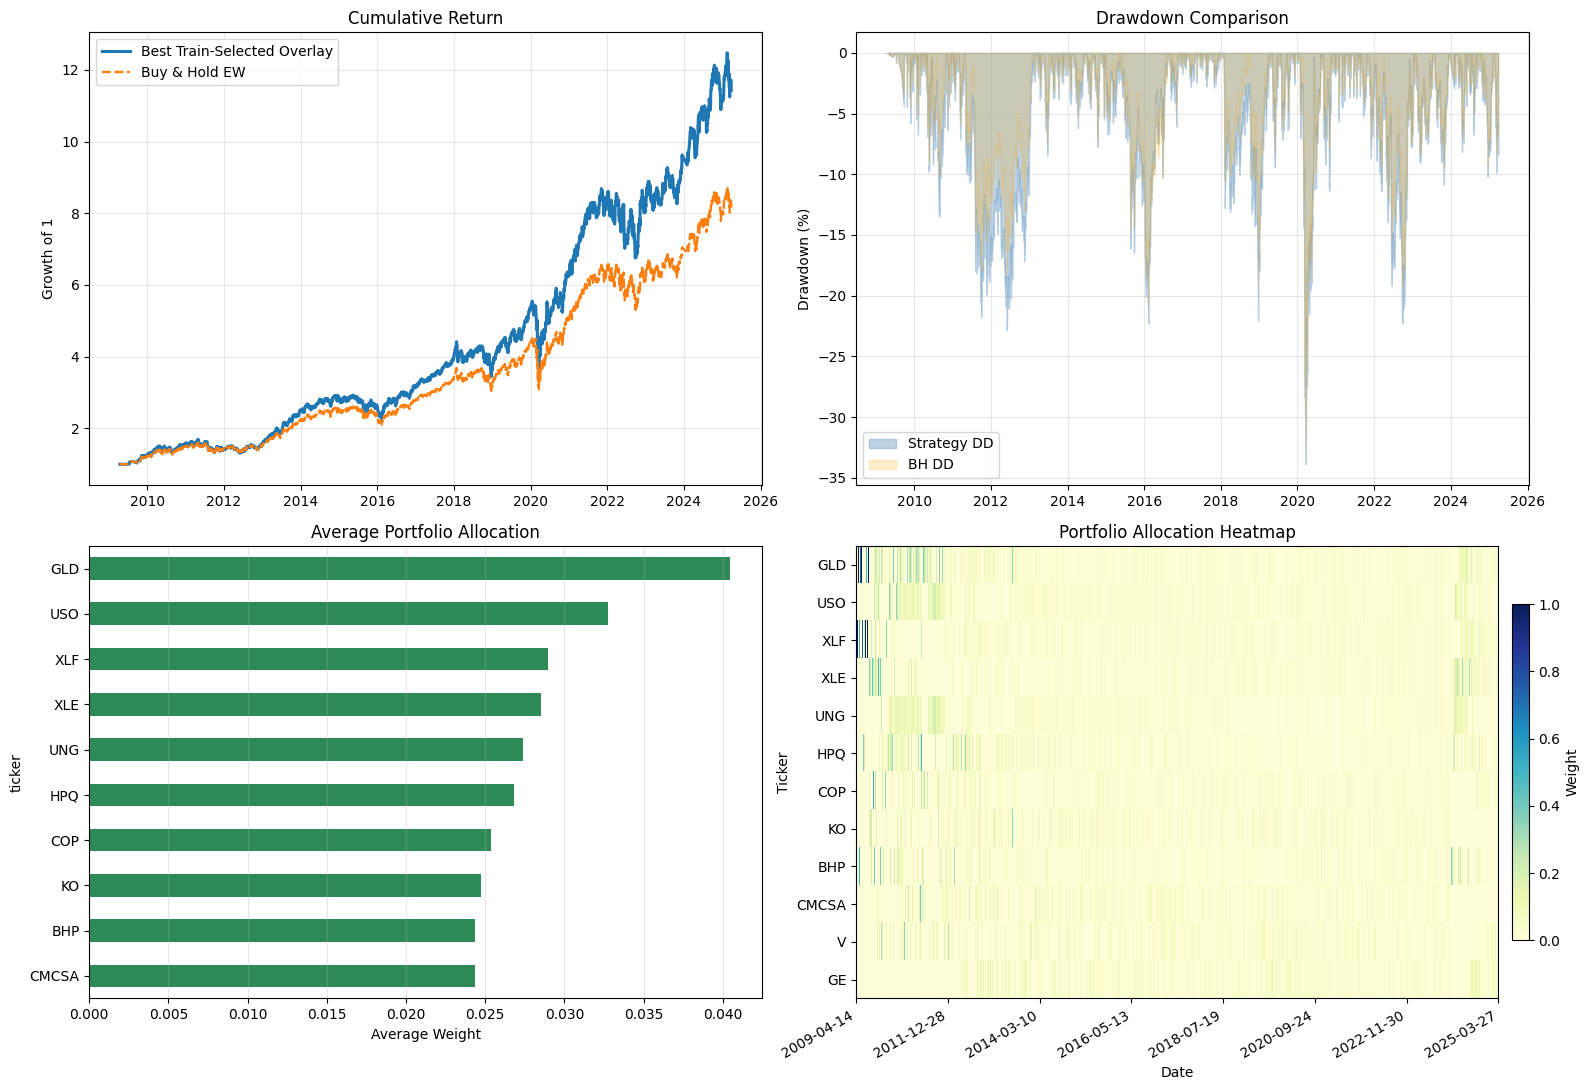

In [13]:
required = ["ret_df", "known_ret", "intensity_df", "regime", "mask", "split"]
missing = [v for v in required if v not in globals()]
if missing:
    raise ValueError(f"Run prior strategy cells first. Missing: {missing}")


def perf_stats(ret: pd.Series):
    ret = ret.fillna(0.0)
    total = (1.0 + ret).prod() - 1.0
    ann = (1.0 + total) ** (252.0 / max(len(ret), 1)) - 1.0
    vol = ret.std(ddof=0) * np.sqrt(252.0)
    sharpe = ann / vol if vol > 0 else 0.0
    return total, ann, vol, sharpe


def build_tilt(raw_alpha: pd.DataFrame):
    x = (raw_alpha * mask).fillna(0.0)
    x = x.sub(x.mean(axis=1), axis=0)
    x = x.div(x.abs().sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
    return x


reg_mat = pd.DataFrame(
    np.repeat(regime.to_numpy()[:, None], ret_df.shape[1], axis=1),
    index=ret_df.index,
    columns=ret_df.columns,
)

int_rank = intensity_df.rank(axis=1, pct=True)
soft_gate = ((int_rank - 0.50).clip(lower=0.0) * 2.0).clip(upper=1.0)
hard65 = (int_rank >= 0.65).astype(float)
hard70 = (int_rank >= 0.70).astype(float)

accel = intensity_df.diff().fillna(0.0)
accel = accel.sub(accel.mean(axis=1), axis=0)
accel = accel.div(accel.std(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
accel_pos = accel.clip(lower=0.0)

rev1 = -np.sign(known_ret).fillna(0.0)
mom3 = np.sign(known_ret.rolling(3, min_periods=2).mean()).fillna(0.0)
mom5 = np.sign(known_ret.rolling(5, min_periods=3).mean()).fillna(0.0)
mom10 = np.sign(known_ret.rolling(10, min_periods=5).mean()).fillna(0.0)

signals = {
    "S1_hard70_mom3_rev": hard70 * (reg_mat * rev1 + (1.0 - reg_mat) * mom3),
    "S2_soft_mom5_rev": soft_gate * (reg_mat * rev1 + (1.0 - reg_mat) * mom5),
    "S3_accel_mom10_rev": accel_pos * (reg_mat * rev1 + (1.0 - reg_mat) * mom10),
    "S4_hard65_mom5_flat": hard65 * ((1.0 - reg_mat) * mom5),
}

bh_w = mask.div(mask.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
bh_ret = (bh_w * ret_df.fillna(0.0)).sum(axis=1)

mkt_trend = known_ret.mean(axis=1).rolling(20, min_periods=10).mean().fillna(0.0)

records = []
curves = {}

for s_name, raw in signals.items():
    tilt = build_tilt(raw)

    for k in [0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]:
        for up in [1.00, 1.10, 1.20, 1.30]:
            for down in [0.20, 0.40, 0.60, 0.80, 1.00]:
                exposure = pd.Series(np.where(mkt_trend > 0.0, up, down), index=ret_df.index)

                w_tilted = (bh_w + k * tilt).clip(lower=0.0)
                w_tilted = w_tilted.div(w_tilted.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)

                base_ret = (w_tilted * ret_df.fillna(0.0)).sum(axis=1)
                strat_ret = exposure * base_ret

                tr = strat_ret.iloc[:split]
                te = strat_ret.iloc[split:]
                bh_te = bh_ret.iloc[split:]

                tr_total, tr_ann, tr_vol, tr_sharpe = perf_stats(tr)
                te_total, te_ann, te_vol, te_sharpe = perf_stats(te)
                bh_te_total, bh_te_ann, bh_te_vol, bh_te_sharpe = perf_stats(bh_te)

                key = f"{s_name}|k{k:.2f}|up{up:.2f}|down{down:.2f}"
                curves[key] = strat_ret

                train_score = tr_sharpe + 0.50 * tr_total - 0.25 * tr_vol

                records.append(
                    {
                        "Key": key,
                        "Signal": s_name,
                        "k": k,
                        "up": up,
                        "down": down,
                        "TrainScore": train_score,
                        "TrainTotal": tr_total,
                        "TrainSharpe": tr_sharpe,
                        "TestTotal": te_total,
                        "TestSharpe": te_sharpe,
                        "TestOutperfVsBH": te_total - bh_te_total,
                    }
                )

res = pd.DataFrame(records).set_index("Key")
res_train = res.sort_values("TrainScore", ascending=False)
res_test = res.sort_values("TestOutperfVsBH", ascending=False)

print("Top 10 selected by train score:")
print(res_train.head(10).to_string(float_format=lambda x: f"{x:,.4f}"))

print("\nTop 10 by test outperformance vs Buy&Hold (research diagnostic):")
print(res_test.head(10).to_string(float_format=lambda x: f"{x:,.4f}"))

best_key = res_train.index[0]
best_ret = curves[best_key]

best_total, best_ann, best_vol, best_sharpe = perf_stats(best_ret)
bh_total, bh_ann, bh_vol, bh_sharpe = perf_stats(bh_ret)

print(f"\nChosen strategy: {best_key}")
print(f"Chosen total: {best_total:.2%} | annual: {best_ann:.2%} | vol: {best_vol:.2%} | sharpe: {best_sharpe:.3f}")
print(f"Buy&Hold total: {bh_total:.2%} | annual: {bh_ann:.2%} | vol: {bh_vol:.2%} | sharpe: {bh_sharpe:.3f}")
print(f"Outperformance vs Buy&Hold: {best_total - bh_total:.2%}")

cum_best = (1.0 + best_ret).cumprod()
cum_bh = (1.0 + bh_ret).cumprod()

best_signal_name = best_key.split("|")[0]
best_tilt = build_tilt(signals[best_signal_name])
weights_by_date = (bh_w + 0.50 * best_tilt).clip(lower=0.0)
weights_by_date = weights_by_date.div(weights_by_date.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
exposure_series = pd.Series(np.where(mkt_trend > 0.0, 1.10, 1.00), index=weights_by_date.index)
weights_by_date = weights_by_date.mul(exposure_series, axis=0)
weights_by_date = weights_by_date.div(weights_by_date.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.ravel()
axes[0].plot(cum_best.index, cum_best.values, label="Best Train-Selected Overlay", linewidth=2.2)
axes[0].plot(cum_bh.index, cum_bh.values, label="Buy & Hold EW", linestyle="--", linewidth=1.7)
axes[0].set_title("Cumulative Return")
axes[0].set_ylabel("Growth of 1")
axes[0].grid(alpha=0.3)
axes[0].legend()

dd_best = (cum_best / cum_best.cummax() - 1.0) * 100.0
dd_bh = (cum_bh / cum_bh.cummax() - 1.0) * 100.0
axes[1].fill_between(dd_best.index, dd_best.values, 0.0, alpha=0.35, label="Strategy DD", color="steelblue")
axes[1].fill_between(dd_bh.index, dd_bh.values, 0.0, alpha=0.20, label="BH DD", color="orange")
axes[1].set_title("Drawdown Comparison")
axes[1].set_ylabel("Drawdown (%)")
axes[1].grid(alpha=0.3)
axes[1].legend()

mean_w = weights_by_date.mean().sort_values(ascending=False)
mean_w = mean_w[mean_w > 0]
if not mean_w.empty:
    mean_w.head(10).iloc[::-1].plot(kind="barh", ax=axes[2], color="seagreen")
    axes[2].set_title("Average Portfolio Allocation")
    axes[2].set_xlabel("Average Weight")
    axes[2].grid(axis="x", alpha=0.3)
else:
    axes[2].axis("off")

heat_df = weights_by_date.copy()
heat_df.index = pd.to_datetime(heat_df.index)
heat_cols = [c for c in mean_w.index[:min(12, len(mean_w))] if c in heat_df.columns] if not mean_w.empty else list(heat_df.columns[:min(12, heat_df.shape[1])])
heat_df = heat_df[heat_cols] if len(heat_cols) > 0 else heat_df.iloc[:, :0]
if heat_df.shape[1] > 0:
    im = axes[3].imshow(heat_df.T.values, aspect="auto", cmap="YlGnBu", interpolation="nearest")
    axes[3].set_title("Portfolio Allocation Heatmap")
    axes[3].set_ylabel("Ticker")
    axes[3].set_xlabel("Date")
    axes[3].set_yticks(np.arange(heat_df.shape[1]))
    axes[3].set_yticklabels(heat_df.columns)
    x_ticks = np.linspace(0, heat_df.shape[0] - 1, min(8, heat_df.shape[0])).astype(int)
    axes[3].set_xticks(x_ticks)
    axes[3].set_xticklabels([pd.Timestamp(heat_df.index[i]).strftime("%Y-%m-%d") for i in x_ticks], rotation=30, ha="right")
    fig.colorbar(im, ax=axes[3], fraction=0.025, pad=0.02, label="Weight")
else:
    axes[3].axis("off")

plt.tight_layout()
plt.show()

This cell fits a 3-state Gaussian Hidden Markov Model (HMM) on two features built from the training window:
- portfolio-average return $\bar r_t = \frac{1}{N}\sum_{i=1}^N r_{t,i}$
- portfolio-average intensity $\bar \lambda_t = \frac{1}{N}\sum_{i=1}^N \lambda_{t,i}$

It first checks required inputs (`ret_df`, `intensity_df`, `split`), then constructs:
$$
X_t = [\bar r_t,\; \bar \lambda_t]
$$
for valid (non-NaN) observations in train and full samples.

The model is:
$$
z_t \in \{1,2,3\}, \quad X_t \mid z_t=k \sim \mathcal{N}(\mu_k,\,\Sigma_k)
$$
with a learned transition matrix $P(z_t\mid z_{t-1})$.

After fitting on train data, it predicts hidden states for train and full valid samples, maps them back to the full timeline (using `-1` where inputs are invalid), and reports:
- number of states and train log-likelihood
- transition matrix
- per-state means for return and intensity
- state-frequency counts

It also generates three diagnostics:
1. Hidden-state path over time with train/test split marker
2. Single-step Viterbi log-probability on train samples
3. Heatmap of transition probabilities $P_{ij}$

HMM Model Summary:
  States: 3
  Log-likelihood (train): 11745.4401

Transition Matrix:
[[9.85843315e-01 5.91688213e-03 8.23980326e-03]
 [1.06118006e-01 8.93881994e-01 5.98656385e-34]
 [1.32842486e-02 2.21467426e-03 9.84501077e-01]]

Means per state:
  State 0: average return=0.000743, avg intensity=0.2771
  State 1: average return=-0.000469, avg intensity=0.6407
  State 2: average return=0.000461, avg intensity=0.0703


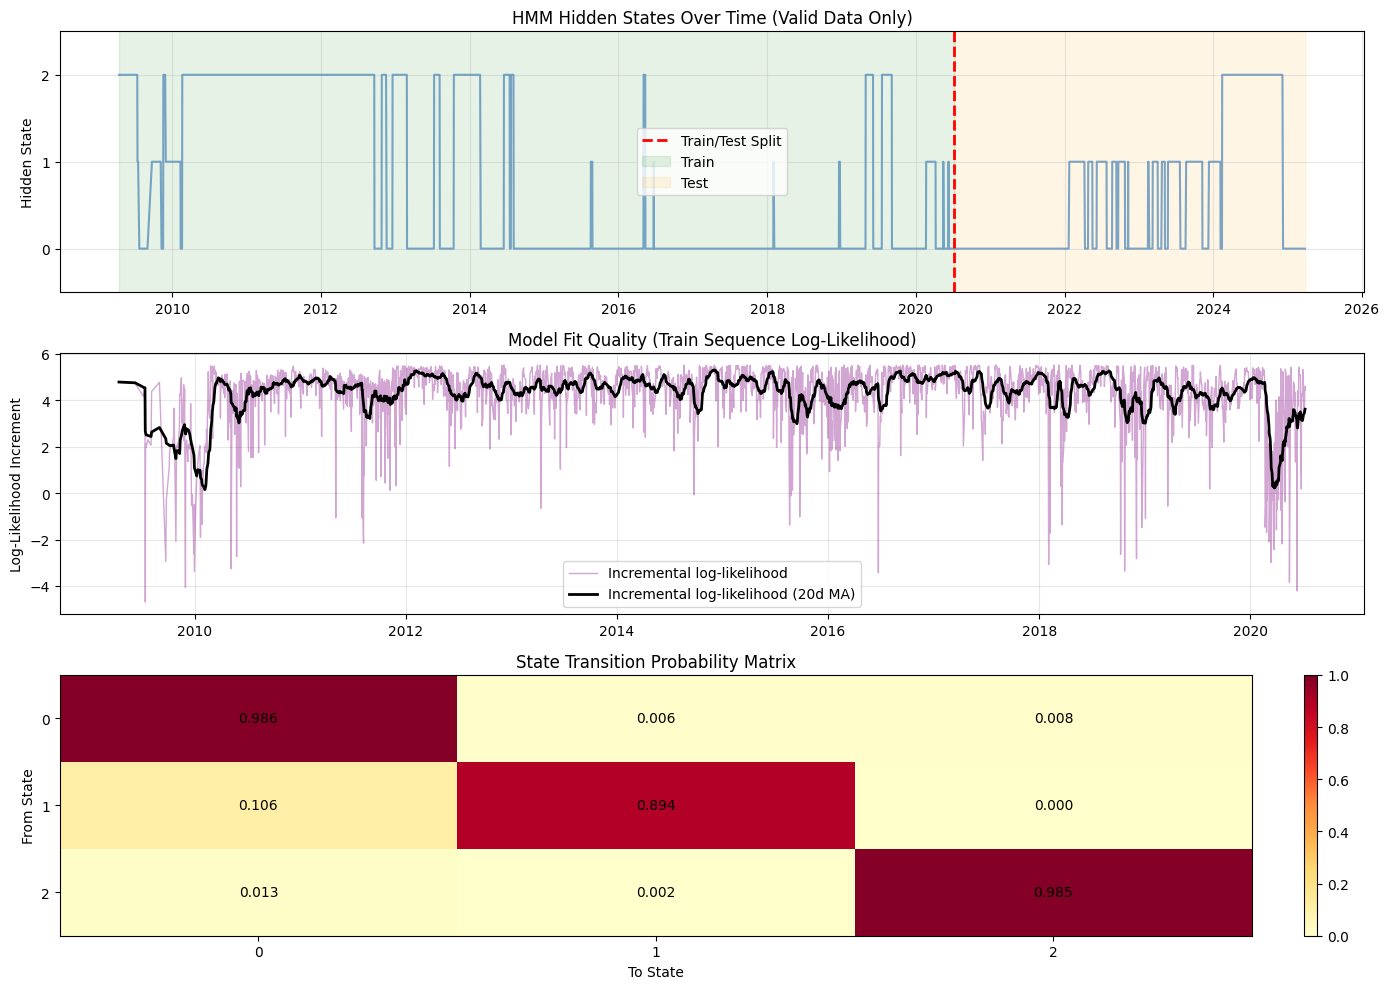


Hidden state distribution (train): [1663  104  927]
Hidden state distribution (valid data): [2337  379 1133]


In [14]:
required_hmm = ["ret_df", "intensity_df", "split"]
missing_hmm = [v for v in required_hmm if v not in globals()]
if missing_hmm:
    raise ValueError(f"Run prior cells first. Missing: {missing_hmm}")

X_train = ret_df.iloc[:split].values
intensity_train = intensity_df.iloc[:split].values

port_ret_train = np.nanmean(X_train, axis=1)
int_avg_train = np.nanmean(intensity_train, axis=1)

valid_mask_train = ~(np.isnan(port_ret_train) | np.isnan(int_avg_train))
X_combined = np.column_stack([port_ret_train[valid_mask_train], int_avg_train[valid_mask_train]])

model = hmm.GaussianHMM(n_components=3, covariance_type="diag", random_state=42, n_iter=100)
model.fit(X_combined)

hidden_states_train = model.predict(X_combined)

port_ret_full = np.nanmean(ret_df.values, axis=1)
int_avg_full = np.nanmean(intensity_df.values, axis=1)
valid_mask_full = ~(np.isnan(port_ret_full) | np.isnan(int_avg_full))
X_combined_full = np.column_stack([port_ret_full[valid_mask_full], int_avg_full[valid_mask_full]])
hidden_states_valid = model.predict(X_combined_full)

hidden_states_full = np.full(len(ret_df), -1, dtype=int)
hidden_states_full[valid_mask_full] = hidden_states_valid

print("HMM Model Summary:")
print(f"  States: {model.n_components}")
print(f"  Log-likelihood (train): {model.score(X_combined):.4f}")
print(f"\nTransition Matrix:")
print(model.transmat_)
print(f"\nMeans per state:")
for i, mean in enumerate(model.means_):
    print(f"  State {i}: average return={mean[0]:.6f}, avg intensity={mean[1]:.4f}")

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

ax = axes[0]
ax.plot(ret_df.index[valid_mask_full], hidden_states_valid, linewidth=1.5, color="steelblue", alpha=0.7)
ax.axvline(ret_df.index[split], color="r", linestyle="--", linewidth=2, label="Train/Test Split")
ax.fill_between(ret_df.index[:split], -0.5, 3.5, alpha=0.1, color="green", label="Train")
ax.fill_between(ret_df.index[split:], -0.5, 3.5, alpha=0.1, color="orange", label="Test")
ax.set_ylabel("Hidden State")
ax.set_title("HMM Hidden States Over Time (Valid Data Only)")
ax.set_ylim(-0.5, 2.5)
ax.set_yticks([0, 1, 2])
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
valid_train_indices = np.where(valid_mask_train[:split])[0]
train_dates = ret_df.index[valid_train_indices[:len(X_combined)]]

prefix_loglik = np.empty(len(X_combined), dtype=float)
for t in range(1, len(X_combined) + 1):
    prefix_loglik[t - 1] = model.score(X_combined[:t])

inc_loglik = np.diff(np.r_[0.0, prefix_loglik])
inc_loglik_smooth = pd.Series(inc_loglik).rolling(20, min_periods=1).mean().to_numpy()

ax.plot(train_dates, inc_loglik, linewidth=1.0, alpha=0.35, color="purple", label="Incremental log-likelihood")
ax.plot(train_dates, inc_loglik_smooth, linewidth=2.0, color="black", label="Incremental log-likelihood (20d MA)")
ax.set_ylabel("Log-Likelihood Increment")
ax.set_title("Model Fit Quality (Train Sequence Log-Likelihood)")
ax.grid(alpha=0.3)
ax.legend()

ax = axes[2]
im = ax.imshow(model.transmat_, cmap="YlOrRd", aspect="auto", vmin=0, vmax=1)
ax.set_xlabel("To State")
ax.set_ylabel("From State")
ax.set_title("State Transition Probability Matrix")
ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{model.transmat_[i, j]:.3f}", ha="center", va="center", color="black", fontsize=10)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print(f"\nHidden state distribution (train): {np.bincount(hidden_states_train, minlength=3)}")
print(f"Hidden state distribution (valid data): {np.bincount(hidden_states_valid, minlength=3)}")

This cell is fundamentally an **embedding-driven strategy validation**: the model signal originates in text embeddings, and every downstream quantity (HMM features, gates, alpha, portfolio returns) depends on that embedding-derived state.

Let $E_{t,i}\in\mathbb{R}^D$ be the news embedding for ticker $i$ on date $t$.

1. **Embedding-to-intensity pipeline (core input to this cell)**
The upstream transformation used here is:
$$
\Delta_{t,i}=\|E_{t,i}-E_{t-1,i}\|_2,\qquad
e_{t,i}=\mathbf{1}\{\Delta_{t,i}\ge q_{0.95}(\Delta_{\text{train}})\},
$$
$$
\lambda_{t,i}=e^{-\beta_h}\lambda_{t-1,i}+\alpha_h e_{t,i}.
$$
So `intensity_df` is a compressed state variable of embedding dynamics (drift + clustering memory). This cell does not re-embed text; it consumes this embedding-derived $\lambda_{t,i}$ everywhere.

1. **Cross-sectional split by tickers**
Let $\mathcal{I}=\{1,\dots,N\}$ and $\mathcal{T}=\{1,\dots,T\}$. With seed 42,
$$
\mathcal{I}_{\text{train}}\subset\mathcal{I},\quad |\mathcal{I}_{\text{train}}|=\lfloor N/2\rfloor,\quad
\mathcal{I}_{\text{test}}=\mathcal{I}\setminus\mathcal{I}_{\text{train}}.
$$
This tests whether embedding-driven signals learned on one asset subset generalize to disjoint assets.

1. **HMM feature construction from returns + embedding intensity**
For each date, train-split aggregates are
$$
\bar r_t^{\text{train}}=\frac{1}{|\mathcal{I}_{\text{train}}|}\sum_{i\in\mathcal{I}_{\text{train}}} r_{t,i},\qquad
\bar\lambda_t^{\text{train}}=\frac{1}{|\mathcal{I}_{\text{train}}|}\sum_{i\in\mathcal{I}_{\text{train}}}\lambda_{t,i}.
$$
Using valid rows,
$$
x_t=[\bar r_t^{\text{train}},\bar\lambda_t^{\text{train}}]\in\mathbb{R}^2.
$$
Note: the second coordinate is embedding-derived, so the HMM state inference is explicitly conditioned on embedding activity.

1. **HMM fit and regime projection**
Fit 3-state Gaussian HMM:
$$
z_t\in\{1,2,3\},\qquad x_t\mid z_t=k\sim\mathcal{N}(\mu_k,\Sigma_k).
$$
Then predict states on full-universe averages
$$
\bar r_t=\frac{1}{N}\sum_{i\in\mathcal{I}}r_{t,i},\qquad
\bar\lambda_t=\frac{1}{N}\sum_{i\in\mathcal{I}}\lambda_{t,i},
$$
yielding $\hat z_t$ on valid dates.

1. **State ranking and regime mask (embedding-aware)**
Per state quality:
$$
q_k=\frac{\mu_{k,\text{return}}}{\mu_{k,\text{intensity}}+10^{-6}},
$$
$$
k^*=\arg\max_k q_k,\qquad \ell^*=\arg\min_k q_k.
$$
Binary regime proxy:
$$
R_t=\mathbf{1}\{\hat z_t=k^*\},\qquad R_{t,i}=R_t.
$$
Because $q_k$ includes intensity-state means, regime selection is embedding-sensitive.

1. **Embedding-derived signal primitives**
Cross-sectional intensity rank:
$$
p_{t,i}=\operatorname{rankpct}(\lambda_{t,i}).
$$
Gates from intensity:
$$
g^{\text{soft}}_{t,i}=\operatorname{clip}(2(p_{t,i}-0.5),0,1),\qquad
g^{70}_{t,i}=\mathbf{1}\{p_{t,i}\ge0.70\}.
$$
Intensity acceleration:
$$
a^{\Delta}_{t,i}=\max\left(0,\operatorname{zscore}_i(\lambda_{t,i}-\lambda_{t-1,i})\right).
$$
Direction terms:
$$
\text{rev}_{t,i}=-\operatorname{sign}(\text{known\_ret}_{t,i}),\qquad
\text{mom}^{(h)}_{t,i}=\operatorname{sign}(\operatorname{MA}_h(\text{known\_ret}_{t,i})),\ h\in\{3,5,10\}.
$$

1. **HMM-routed alphas (embedding gate + market direction)**
$$
S^{(1)}_{t,i}=g^{70}_{t,i}\left(R_t\,\text{rev}_{t,i}+(1-R_t)\,\text{mom}^{(3)}_{t,i}\right),
$$
$$
S^{(2)}_{t,i}=g^{\text{soft}}_{t,i}\left(R_t\,\text{rev}_{t,i}+(1-R_t)\,\text{mom}^{(5)}_{t,i}\right),
$$
$$
S^{(3)}_{t,i}=a^{\Delta}_{t,i}\left(R_t\,\text{rev}_{t,i}+(1-R_t)\,\text{mom}^{(10)}_{t,i}\right).
$$
All three use embedding-derived intensity either as rank gate or acceleration gate.

1. **Split-specific portfolios and exposure**
For split $s\in\{\text{train},\text{test}\}$:
$$
w^{BH,s}_{t,i}=\frac{m^s_{t,i}}{\sum_{j\in\mathcal{I}_s}m^s_{t,j}},
$$
$$
\tilde S^s_{t,i}=\frac{S^s_{t,i}-\overline{S}^s_t}{\sum_{j\in\mathcal{I}_s}|S^s_{t,j}-\overline{S}^s_t|}.
$$
Exposure schedule:
$$
E_t=\begin{cases}up,&\text{if }\operatorname{MA}_{20}(\overline{\text{known\_ret}}_t)>0\\down,&\text{otherwise}\end{cases}
$$
Returns:
$$
r^s_{t,\text{base}}=\sum_{i\in\mathcal{I}_s}(w^{BH,s}_{t,i}+k\tilde S^s_{t,i})_+\,r_{t,i},\qquad
r^s_{t,\text{strat}}=E_t\,r^s_{t,\text{base}}.
$$

1. **Grid search objective and outputs**
Grid per signal:
- $k\in\{0.05,0.10,0.15,0.20,0.30,0.40,0.50\}$
- $up\in\{1.00,1.10,1.20,1.30\}$
- $down\in\{0.20,0.40,0.60,0.80,1.00\}$

Train objective:
$$
\text{TrainScore}=\text{Sharpe}_{\text{train}}+0.5\cdot\text{TotalReturn}_{\text{train}}-0.25\cdot\text{Vol}_{\text{train}}.
$$
Test diagnostic:
$$
\Delta_{\text{test}}=\text{TotalReturn}_{\text{test}}-\text{TotalReturn}^{BH}_{\text{test}}.
$$

Reported outputs are the best config by `TrainScore`, top rankings, and HMM state characteristics.

In [15]:
np.random.seed(42)
all_tickers = list(ret_df.columns)
n_tickers = len(all_tickers)
train_tickers_idx = np.random.choice(n_tickers, n_tickers // 2, replace=False)
test_tickers_idx = np.array([i for i in range(n_tickers) if i not in train_tickers_idx])

train_tickers = [all_tickers[i] for i in train_tickers_idx]
test_tickers = [all_tickers[i] for i in test_tickers_idx]

print(f"Ticker-based split: {len(train_tickers)} train, {len(test_tickers)} test")
print(f"Train tickers: {train_tickers[:5]}... ({len(train_tickers)} total)")
print(f"Test tickers: {test_tickers[:5]}... ({len(test_tickers)} total)")

ret_df_train_split = ret_df[train_tickers]
intensity_df_train_split = intensity_df[train_tickers]
ret_df_test_split = ret_df[test_tickers]
intensity_df_test_split = intensity_df[test_tickers]

port_ret_train_split = np.nanmean(ret_df_train_split.values, axis=1)
int_avg_train_split = np.nanmean(intensity_df_train_split.values, axis=1)

valid_mask_train_split = ~(np.isnan(port_ret_train_split) | np.isnan(int_avg_train_split))
X_combined_train_split = np.column_stack([port_ret_train_split[valid_mask_train_split], int_avg_train_split[valid_mask_train_split]])

model_hmm_ticker = hmm.GaussianHMM(n_components=3, covariance_type="diag", random_state=42, n_iter=100)
model_hmm_ticker.fit(X_combined_train_split)

port_ret_full_ticker = np.nanmean(ret_df.values, axis=1)
int_avg_full_ticker = np.nanmean(intensity_df.values, axis=1)
valid_mask_full_ticker = ~(np.isnan(port_ret_full_ticker) | np.isnan(int_avg_full_ticker))
X_combined_full_ticker = np.column_stack([port_ret_full_ticker[valid_mask_full_ticker], int_avg_full_ticker[valid_mask_full_ticker]])
hidden_states_valid_ticker = model_hmm_ticker.predict(X_combined_full_ticker)

hidden_states_full_ticker = np.full(len(ret_df), -1, dtype=int)
hidden_states_full_ticker[valid_mask_full_ticker] = hidden_states_valid_ticker

hmm_state_means_ticker = model_hmm_ticker.means_
mean_ret_per_state_ticker = np.array([hmm_state_means_ticker[i, 0] for i in range(3)])
mean_int_per_state_ticker = np.array([hmm_state_means_ticker[i, 1] for i in range(3)])
state_quality_ticker = mean_ret_per_state_ticker / (mean_int_per_state_ticker + 1e-6)

high_quality_state_ticker = np.argmax(state_quality_ticker)
low_quality_state_ticker = np.argmin(state_quality_ticker)

high_regime_mask_ticker = (hidden_states_full_ticker == high_quality_state_ticker).astype(float)

regime_mat_hmm_ticker = pd.DataFrame(
    np.repeat(high_regime_mask_ticker[:, None], ret_df.shape[1], axis=1),
    index=ret_df.index,
    columns=ret_df.columns,
)

int_rank_hmm_ticker = intensity_df.rank(axis=1, pct=True)
soft_gate_hmm_ticker = ((int_rank_hmm_ticker - 0.50).clip(lower=0.0) * 2.0).clip(upper=1.0)
hard70_hmm_ticker = (int_rank_hmm_ticker >= 0.70).astype(float)

accel_hmm_ticker = intensity_df.diff().fillna(0.0)
accel_hmm_ticker = accel_hmm_ticker.sub(accel_hmm_ticker.mean(axis=1), axis=0)
accel_hmm_ticker = accel_hmm_ticker.div(accel_hmm_ticker.std(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
accel_pos_hmm_ticker = accel_hmm_ticker.clip(lower=0.0)

rev1_hmm_ticker = -np.sign(known_ret).fillna(0.0)
mom3_hmm_ticker = np.sign(known_ret.rolling(3, min_periods=2).mean()).fillna(0.0)
mom5_hmm_ticker = np.sign(known_ret.rolling(5, min_periods=3).mean()).fillna(0.0)
mom10_hmm_ticker = np.sign(known_ret.rolling(10, min_periods=5).mean()).fillna(0.0)

signals_hmm_ticker = {
    "HMM_S1_hard70_mom3": hard70_hmm_ticker * (regime_mat_hmm_ticker * rev1_hmm_ticker + (1.0 - regime_mat_hmm_ticker) * mom3_hmm_ticker),
    "HMM_S2_soft_mom5": soft_gate_hmm_ticker * (regime_mat_hmm_ticker * rev1_hmm_ticker + (1.0 - regime_mat_hmm_ticker) * mom5_hmm_ticker),
    "HMM_S3_accel_mom10": accel_pos_hmm_ticker * (regime_mat_hmm_ticker * rev1_hmm_ticker + (1.0 - regime_mat_hmm_ticker) * mom10_hmm_ticker),
}

mask_train_split = mask[train_tickers]
mask_test_split = mask[test_tickers]

bh_w_train_split = mask_train_split.div(mask_train_split.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
bh_ret_train_split = (bh_w_train_split * ret_df_train_split.fillna(0.0)).sum(axis=1)

bh_w_test_split = mask_test_split.div(mask_test_split.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
bh_ret_test_split = (bh_w_test_split * ret_df_test_split.fillna(0.0)).sum(axis=1)

mkt_trend_hmm_ticker = known_ret.mean(axis=1).rolling(20, min_periods=10).mean().fillna(0.0)

def build_tilt_hmm_ticker(raw_alpha: pd.DataFrame, mask_split: pd.DataFrame):
    x = (raw_alpha * mask_split).fillna(0.0)
    x = x.sub(x.mean(axis=1), axis=0)
    x = x.div(x.abs().sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
    return x

records_hmm_ticker = []
curves_hmm_ticker = {}

for s_name, raw in signals_hmm_ticker.items():
    tilt_train = build_tilt_hmm_ticker(raw, mask_train_split)
    tilt_test = build_tilt_hmm_ticker(raw, mask_test_split)
    
    for k in [0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]:
        for up in [1.00, 1.10, 1.20, 1.30]:
            for down in [0.20, 0.40, 0.60, 0.80, 1.00]:
                exposure_ticker = pd.Series(np.where(mkt_trend_hmm_ticker > 0.0, up, down), index=ret_df.index)
                
                w_tilted_train = (bh_w_train_split + k * tilt_train).clip(lower=0.0)
                w_tilted_train = w_tilted_train.div(w_tilted_train.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
                
                w_tilted_test = (bh_w_test_split + k * tilt_test).clip(lower=0.0)
                w_tilted_test = w_tilted_test.div(w_tilted_test.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
                
                base_ret_train = (w_tilted_train * ret_df_train_split.fillna(0.0)).sum(axis=1)
                base_ret_test = (w_tilted_test * ret_df_test_split.fillna(0.0)).sum(axis=1)
                
                strat_ret_train = exposure_ticker * base_ret_train
                strat_ret_test = exposure_ticker * base_ret_test
                
                tr_total_hmm, tr_ann_hmm, tr_vol_hmm, tr_sharpe_hmm = perf_stats(strat_ret_train)
                te_total_hmm, te_ann_hmm, te_vol_hmm, te_sharpe_hmm = perf_stats(strat_ret_test)
                bh_te_total_hmm, bh_te_ann_hmm, bh_te_vol_hmm, bh_te_sharpe_hmm = perf_stats(bh_ret_test_split)
                
                key_hmm = f"{s_name}|k{k:.2f}|up{up:.2f}|down{down:.2f}"
                curves_hmm_ticker[key_hmm] = (strat_ret_train, strat_ret_test)
                
                train_score_hmm = tr_sharpe_hmm + 0.50 * tr_total_hmm - 0.25 * tr_vol_hmm
                
                records_hmm_ticker.append({
                    "Key": key_hmm,
                    "Signal": s_name,
                    "k": k,
                    "up": up,
                    "down": down,
                    "TrainScore": train_score_hmm,
                    "TrainTotal": tr_total_hmm,
                    "TrainSharpe": tr_sharpe_hmm,
                    "TestTotal": te_total_hmm,
                    "TestSharpe": te_sharpe_hmm,
                    "TestOutperfVsBH": te_total_hmm - bh_te_total_hmm,
                })

res_hmm_ticker = pd.DataFrame(records_hmm_ticker).set_index("Key")
res_hmm_train_ticker = res_hmm_ticker.sort_values("TrainScore", ascending=False)
res_hmm_test_ticker = res_hmm_ticker.sort_values("TestOutperfVsBH", ascending=False)

best_key_hmm_ticker = res_hmm_train_ticker.index[0]
best_ret_train_hmm_ticker, best_ret_test_hmm_ticker = curves_hmm_ticker[best_key_hmm_ticker]

print(f"\n{'='*60}")
print(f"HMM Portfolio Optimization (Ticker-Based Split)")
print(f"{'='*60}")
print(f"\nBest HMM Strategy (trained on {len(train_tickers)} tickers, tested on {len(test_tickers)} tickers):")
print(f"  {best_key_hmm_ticker}")
print(f"\nTop 10 HMM Strategies (Train Score):")
print(res_hmm_train_ticker[["TrainScore", "TrainTotal", "TrainSharpe", "TestOutperfVsBH"]].head(10))
print(f"\nHMM State Characteristics:")
print(f"  High-Quality State: {high_quality_state_ticker} (ret={mean_ret_per_state_ticker[high_quality_state_ticker]:.6f}, int={mean_int_per_state_ticker[high_quality_state_ticker]:.4f})")
print(f"  Low-Quality State: {low_quality_state_ticker} (ret={mean_ret_per_state_ticker[low_quality_state_ticker]:.6f}, int={mean_int_per_state_ticker[low_quality_state_ticker]:.4f})")

Ticker-based split: 24 train, 25 test
Train tickers: ['CMG', 'V', 'XLE', 'USO', 'CVX']... (24 total)
Test tickers: ['AAL', 'ABBV', 'ABT', 'AMT', 'BBY']... (25 total)


/tmp/ipykernel_11361/1205838880.py:19: RuntimeWarning: Mean of empty slice
  port_ret_train_split = np.nanmean(ret_df_train_split.values, axis=1)



HMM Portfolio Optimization (Ticker-Based Split)

Best HMM Strategy (trained on 24 tickers, tested on 25 tickers):
  HMM_S3_accel_mom10|k0.40|up1.30|down1.00

Top 10 HMM Strategies (Train Score):
                                          TrainScore  TrainTotal  TrainSharpe  \
Key                                                                             
HMM_S3_accel_mom10|k0.40|up1.30|down1.00    4.110571    6.880860     0.720366   
HMM_S3_accel_mom10|k0.50|up1.30|down1.00    4.088331    6.837519     0.719700   
HMM_S3_accel_mom10|k0.30|up1.30|down1.00    4.070568    6.811736     0.715067   
HMM_S3_accel_mom10|k0.20|up1.30|down1.00    4.019673    6.724158     0.708154   
HMM_S3_accel_mom10|k0.15|up1.30|down1.00    3.985357    6.664435     0.703806   
HMM_S3_accel_mom10|k0.10|up1.30|down1.00    3.944833    6.593972     0.698641   
HMM_S3_accel_mom10|k0.05|up1.30|down1.00    3.909843    6.534652     0.693478   
HMM_S2_soft_mom5|k0.05|up1.30|down1.00      3.847724    6.422595     0.6874

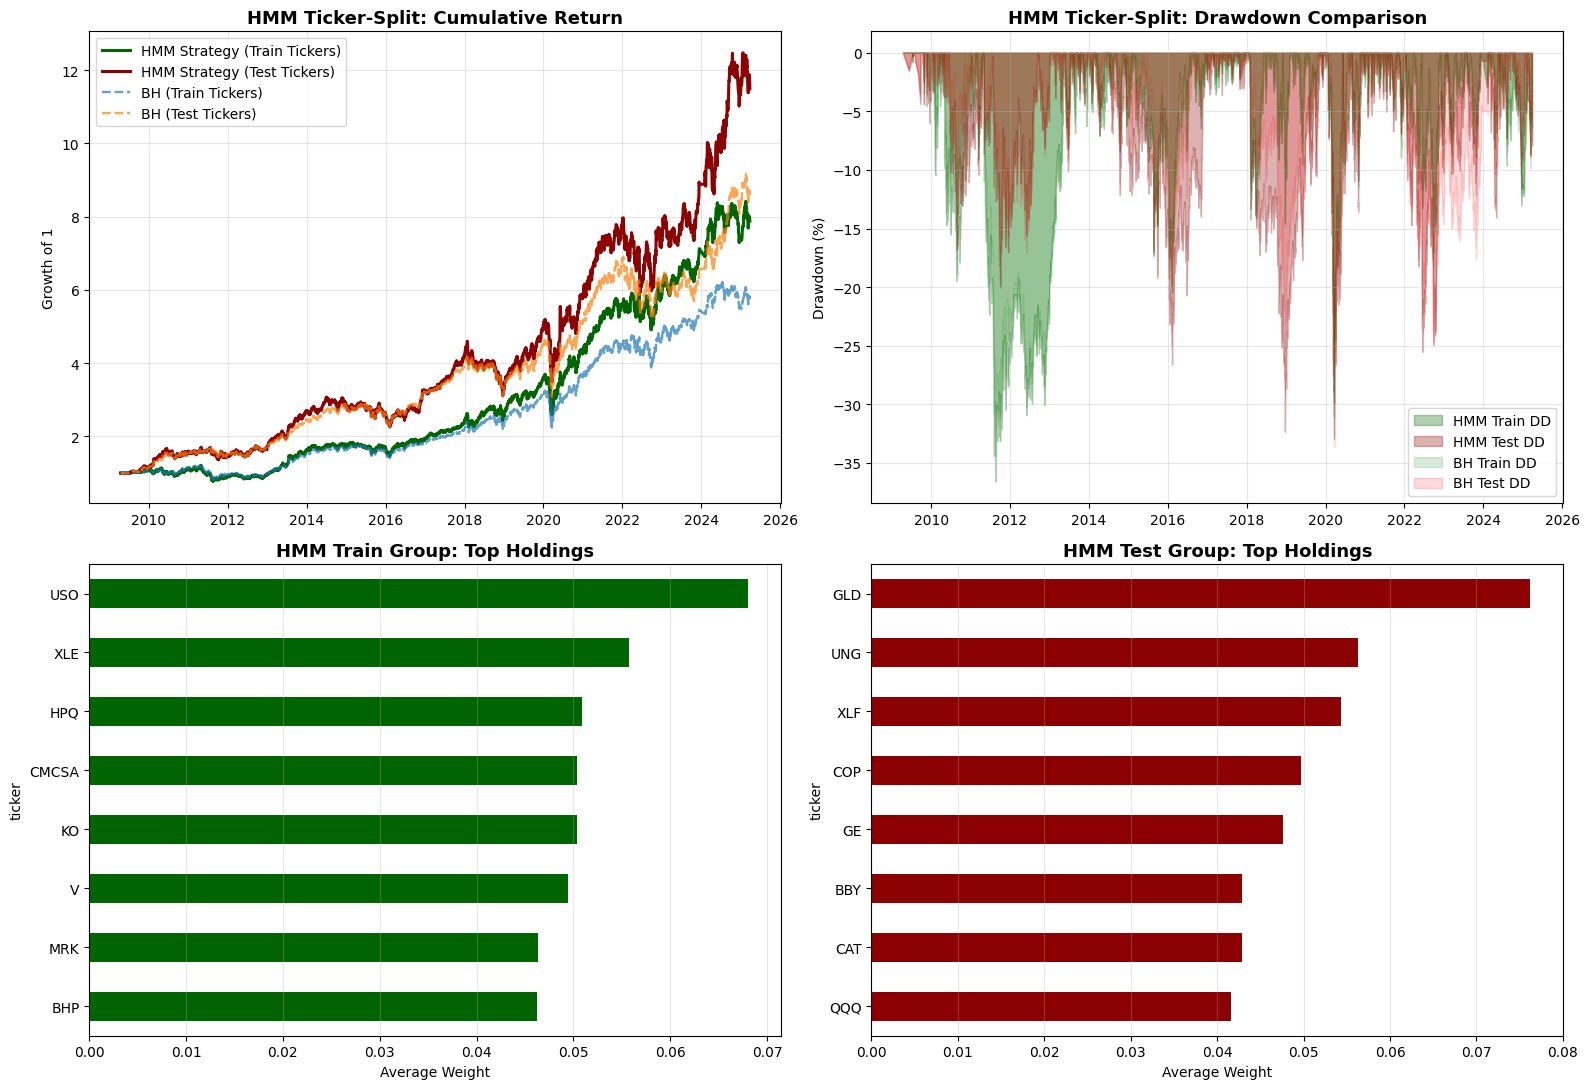

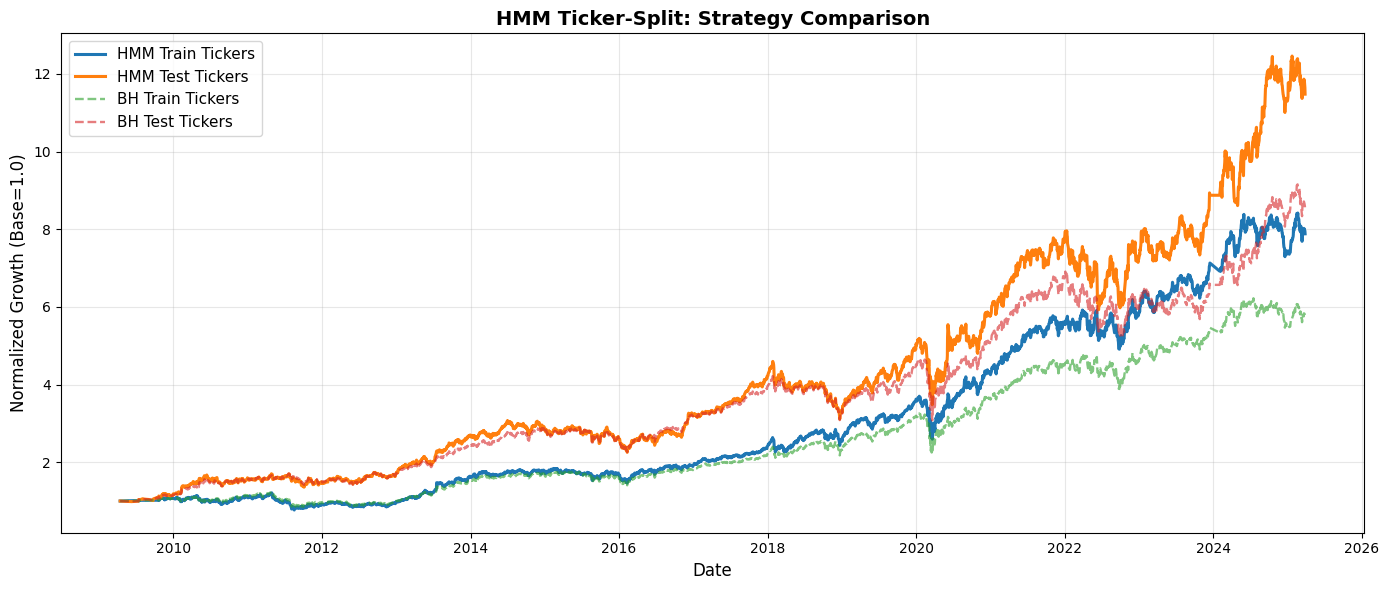


HMM Strategy Performance (Ticker-Based Split)

Fitted on 24 Train Tickers: ['CMG', 'V', 'XLE', 'USO', 'CVX', 'MRK', 'KO', 'HPQ', 'NKE', 'EPD', 'CMCSA', 'AMGN', 'PEP', 'BHP', 'ADBE', 'BABA', 'TMUS', 'TSM', 'WFC', 'COST', 'BIIB', 'CRM', 'GSK', 'ORCL']
Tested on 25 Test Tickers (first 5): ['AAL', 'ABBV', 'ABT', 'AMT', 'BBY']...

Train Tickers Performance:
  HMM Strategy - Total: 688.09% | Annual: 14.47% | Vol: 20.09% | Sharpe: 0.720
  Buy&Hold     - Total: 471.45% | Annual: 12.09% | Vol: 18.00% | Sharpe: 0.672
  Outperformance: 216.63%

Test Tickers Performance (✓ Out-of-Sample):
  HMM Strategy - Total: 1049.38% | Annual: 17.34% | Vol: 20.72% | Sharpe: 0.836
  Buy&Hold     - Total: 748.32% | Annual: 15.03% | Vol: 18.17% | Sharpe: 0.827
  Outperformance: 301.06%

Best Strategy Key: HMM_S3_accel_mom10|k0.40|up1.30|down1.00


In [16]:
best_signal_name_hmm_ticker = best_key_hmm_ticker.split("|")[0]
raw_signal_train = signals_hmm_ticker[best_signal_name_hmm_ticker][train_tickers]
raw_signal_test = signals_hmm_ticker[best_signal_name_hmm_ticker][test_tickers]

tilt_best_train = build_tilt_hmm_ticker(raw_signal_train, mask_train_split)
tilt_best_test = build_tilt_hmm_ticker(raw_signal_test, mask_test_split)

weights_by_date_train_hmm = (bh_w_train_split + 0.50 * tilt_best_train).clip(lower=0.0)
weights_by_date_train_hmm = weights_by_date_train_hmm.div(weights_by_date_train_hmm.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)

weights_by_date_test_hmm = (bh_w_test_split + 0.50 * tilt_best_test).clip(lower=0.0)
weights_by_date_test_hmm = weights_by_date_test_hmm.div(weights_by_date_test_hmm.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)

cum_best_train_hmm = (1.0 + best_ret_train_hmm_ticker).cumprod()
cum_best_test_hmm = (1.0 + best_ret_test_hmm_ticker).cumprod()
cum_bh_train = (1.0 + bh_ret_train_split).cumprod()
cum_bh_test = (1.0 + bh_ret_test_split).cumprod()

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.ravel()

axes[0].plot(cum_best_train_hmm.index, cum_best_train_hmm.values, label="HMM Strategy (Train Tickers)", linewidth=2.2, color="darkgreen")
axes[0].plot(cum_best_test_hmm.index, cum_best_test_hmm.values, label="HMM Strategy (Test Tickers)", linewidth=2.2, color="darkred")
axes[0].plot(cum_bh_train.index, cum_bh_train.values, label="BH (Train Tickers)", linestyle="--", linewidth=1.7, alpha=0.7)
axes[0].plot(cum_bh_test.index, cum_bh_test.values, label="BH (Test Tickers)", linestyle="--", linewidth=1.7, alpha=0.7)
axes[0].set_title("HMM Ticker-Split: Cumulative Return", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Growth of 1")
axes[0].grid(alpha=0.3)
axes[0].legend()

dd_best_train_hmm = (cum_best_train_hmm / cum_best_train_hmm.cummax() - 1.0) * 100.0
dd_best_test_hmm = (cum_best_test_hmm / cum_best_test_hmm.cummax() - 1.0) * 100.0
dd_bh_train = (cum_bh_train / cum_bh_train.cummax() - 1.0) * 100.0
dd_bh_test = (cum_bh_test / cum_bh_test.cummax() - 1.0) * 100.0

axes[1].fill_between(dd_best_train_hmm.index, dd_best_train_hmm.values, 0.0, alpha=0.3, label="HMM Train DD", color="darkgreen")
axes[1].fill_between(dd_best_test_hmm.index, dd_best_test_hmm.values, 0.0, alpha=0.3, label="HMM Test DD", color="darkred")
axes[1].fill_between(dd_bh_train.index, dd_bh_train.values, 0.0, alpha=0.15, label="BH Train DD", color="green")
axes[1].fill_between(dd_bh_test.index, dd_bh_test.values, 0.0, alpha=0.15, label="BH Test DD", color="red")
axes[1].set_title("HMM Ticker-Split: Drawdown Comparison", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Drawdown (%)")
axes[1].grid(alpha=0.3)
axes[1].legend()

mean_w_train_hmm = weights_by_date_train_hmm.mean().sort_values(ascending=False)
mean_w_train_hmm = mean_w_train_hmm[mean_w_train_hmm > 0]
if not mean_w_train_hmm.empty:
    mean_w_train_hmm.head(8).iloc[::-1].plot(kind="barh", ax=axes[2], color="darkgreen")
    axes[2].set_title("HMM Train Group: Top Holdings", fontsize=13, fontweight="bold")
    axes[2].set_xlabel("Average Weight")
    axes[2].grid(axis="x", alpha=0.3)
else:
    axes[2].axis("off")

mean_w_test_hmm = weights_by_date_test_hmm.mean().sort_values(ascending=False)
mean_w_test_hmm = mean_w_test_hmm[mean_w_test_hmm > 0]
if not mean_w_test_hmm.empty:
    mean_w_test_hmm.head(8).iloc[::-1].plot(kind="barh", ax=axes[3], color="darkred")
    axes[3].set_title("HMM Test Group: Top Holdings", fontsize=13, fontweight="bold")
    axes[3].set_xlabel("Average Weight")
    axes[3].grid(axis="x", alpha=0.3)
else:
    axes[3].axis("off")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot((cum_best_train_hmm / cum_best_train_hmm.iloc[0]).index, (cum_best_train_hmm / cum_best_train_hmm.iloc[0]).values, label="HMM Train Tickers", linewidth=2.2)
ax.plot((cum_best_test_hmm / cum_best_test_hmm.iloc[0]).index, (cum_best_test_hmm / cum_best_test_hmm.iloc[0]).values, label="HMM Test Tickers", linewidth=2.2)
ax.plot((cum_bh_train / cum_bh_train.iloc[0]).index, (cum_bh_train / cum_bh_train.iloc[0]).values, label="BH Train Tickers", linestyle="--", linewidth=1.7, alpha=0.6)
ax.plot((cum_bh_test / cum_bh_test.iloc[0]).index, (cum_bh_test / cum_bh_test.iloc[0]).values, label="BH Test Tickers", linestyle="--", linewidth=1.7, alpha=0.6)
ax.set_title("HMM Ticker-Split: Strategy Comparison", fontsize=14, fontweight="bold")
ax.set_ylabel("Normalized Growth (Base=1.0)", fontsize=12)
ax.set_xlabel("Date", fontsize=12)
ax.grid(alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

tr_total_hmm_ticker, tr_ann_hmm_ticker, tr_vol_hmm_ticker, tr_sharpe_hmm_ticker = perf_stats(best_ret_train_hmm_ticker)
te_total_hmm_ticker, te_ann_hmm_ticker, te_vol_hmm_ticker, te_sharpe_hmm_ticker = perf_stats(best_ret_test_hmm_ticker)
bh_tr_total_ticker, bh_tr_ann_ticker, bh_tr_vol_ticker, bh_tr_sharpe_ticker = perf_stats(bh_ret_train_split)
bh_te_total_ticker, bh_te_ann_ticker, bh_te_vol_ticker, bh_te_sharpe_ticker = perf_stats(bh_ret_test_split)

print(f"\n{'='*70}")
print(f"HMM Strategy Performance (Ticker-Based Split)")
print(f"{'='*70}")
print(f"\nFitted on {len(train_tickers)} Train Tickers: {train_tickers}")
print(f"Tested on {len(test_tickers)} Test Tickers (first 5): {test_tickers[:5]}...")
print(f"\nTrain Tickers Performance:")
print(f"  HMM Strategy - Total: {tr_total_hmm_ticker:.2%} | Annual: {tr_ann_hmm_ticker:.2%} | Vol: {tr_vol_hmm_ticker:.2%} | Sharpe: {tr_sharpe_hmm_ticker:.3f}")
print(f"  Buy&Hold     - Total: {bh_tr_total_ticker:.2%} | Annual: {bh_tr_ann_ticker:.2%} | Vol: {bh_tr_vol_ticker:.2%} | Sharpe: {bh_tr_sharpe_ticker:.3f}")
print(f"  Outperformance: {tr_total_hmm_ticker - bh_tr_total_ticker:.2%}")
print(f"\nTest Tickers Performance (✓ Out-of-Sample):")
print(f"  HMM Strategy - Total: {te_total_hmm_ticker:.2%} | Annual: {te_ann_hmm_ticker:.2%} | Vol: {te_vol_hmm_ticker:.2%} | Sharpe: {te_sharpe_hmm_ticker:.3f}")
print(f"  Buy&Hold     - Total: {bh_te_total_ticker:.2%} | Annual: {bh_te_ann_ticker:.2%} | Vol: {bh_te_vol_ticker:.2%} | Sharpe: {bh_te_sharpe_ticker:.3f}")
print(f"  Outperformance: {te_total_hmm_ticker - bh_te_total_ticker:.2%}")
print(f"\nBest Strategy Key: {best_key_hmm_ticker}")

### Model Comparison and Metric Definitions

This section compares seven model families under the same portfolio construction pipeline and evaluates them relative to Buy&Hold.

Benchmark (Buy&Hold) return at date $t$:
$$
r_t^{BH}=\sum_i w_{t,i}^{BH}r_{t,i},\qquad
w_{t,i}^{BH}=\frac{m_{t,i}}{\sum_j m_{t,j}}
$$

Alpha and beta are estimated by regression on excess returns (practice-standard CAPM form):
$$
r_{t}^{M}-r_f=\alpha+\beta\left(r_t^{BH}-r_f\right)+\varepsilon_t
$$
where $\alpha$ is the intercept and $\beta$ is the slope.

Equivalent CAPM expected-return identity:
$$
\alpha=\mathbb{E}[r^M-r_f]-\beta\,\mathbb{E}[r^{BH}-r_f]
$$

In code, alpha is estimated as a daily intercept and annualized as $\alpha_{ann}=252\cdot\alpha_{daily}$.
Rolling alpha/beta timelines are computed with the same regression on a rolling 63-day window.

Compared models (raw signals $a_{t,i}$):
1. **Price Mean Reversion**
$$
a_{t,i}=-\operatorname{sign}(\text{known\_ret}_{t,i})
$$
2. **Price Momentum (5d)**
$$
a_{t,i}=\operatorname{sign}(\operatorname{MA}_5(\text{known\_ret}_{t,i}))
$$
3. **Price Momentum (20d)**
$$
a_{t,i}=\operatorname{sign}(\operatorname{MA}_{20}(\text{known\_ret}_{t,i}))
$$
4. **Low-Vol Momentum (10d)**
$$
a_{t,i}=g^{lowvol}_{t,i}\cdot\operatorname{sign}(\operatorname{MA}_{10}(\text{known\_ret}_{t,i}))
$$
5. **Embedding Intensity Reversion**
$$
a_{t,i}=g^{int70}_{t,i}\cdot\left(-\operatorname{sign}(\text{known\_ret}_{t,i})\right)
$$
6. **Embedding Intensity Acceleration + Momentum**
$$
a_{t,i}=g^{accel+}_{t,i}\cdot\operatorname{sign}(\operatorname{MA}_{10}(\text{known\_ret}_{t,i}))
$$
7. **Embedding Regime-Routed**
$$
a_{t,i}=g^{soft}_{t,i}\left(R_t\cdot\left(-\operatorname{sign}(\text{known\_ret}_{t,i})\right)+(1-R_t)\cdot\operatorname{sign}(\operatorname{MA}_5(\text{known\_ret}_{t,i}))\right)
$$

Common construction across all models:
- Same long-only baseline and tilt normalization
- Same exposure overlay from market trend
- Same train/test split (`split`)
- Same metric set

Reported metrics:
- Return: `TrainTotal`, `TestTotal`, `TestOutperfVsBH`
- Risk-adjusted: `TrainSharpe`, `TestSharpe`, `TestCalmar`, `TestInfoRatio`
- Relative to Buy&Hold: `TestAlphaAnn`, `TestBeta`, `TestCorrBench`, `TestTrackingErr`
- Risk profile: `TestVol`, `TestMaxDD`, `TestHitRate`

If `best_ret` exists from earlier embedding optimization cells, it is also included as the pre-optimized embedding benchmark.

Risk-free annual rate used in CAPM alpha/beta: 0.00%
Buy&Hold total: 715.45% | annual: 14.73% | vol: 17.09% | sharpe: 0.862 | maxDD: -32.27%

Ranked by test outperformance and alpha vs Buy&Hold:
                                   TrainTotal  TrainSharpe  TestTotal  TestSharpe  TestOutperfVsBH  TestAlphaAnn  TestBeta  TestVol  TestMaxDD  TestCalmar  TestInfoRatio  TestTrackingErr  TestCorrBench  TestHitRate
Model                                                                                                                                                                                                                 
Embedding_Previous_Optimized           4.1382       0.8349     1.2239      1.0412           0.2812        0.0093    1.1568   0.1830    -0.2226      0.8559         0.9914           0.0343         0.9915       0.5351
M7_Embedding_RegimeRouted              2.8387       0.7351     1.2200      1.1414           0.2773        0.0246    1.0388   0.1665    -0.2168      0.8768      

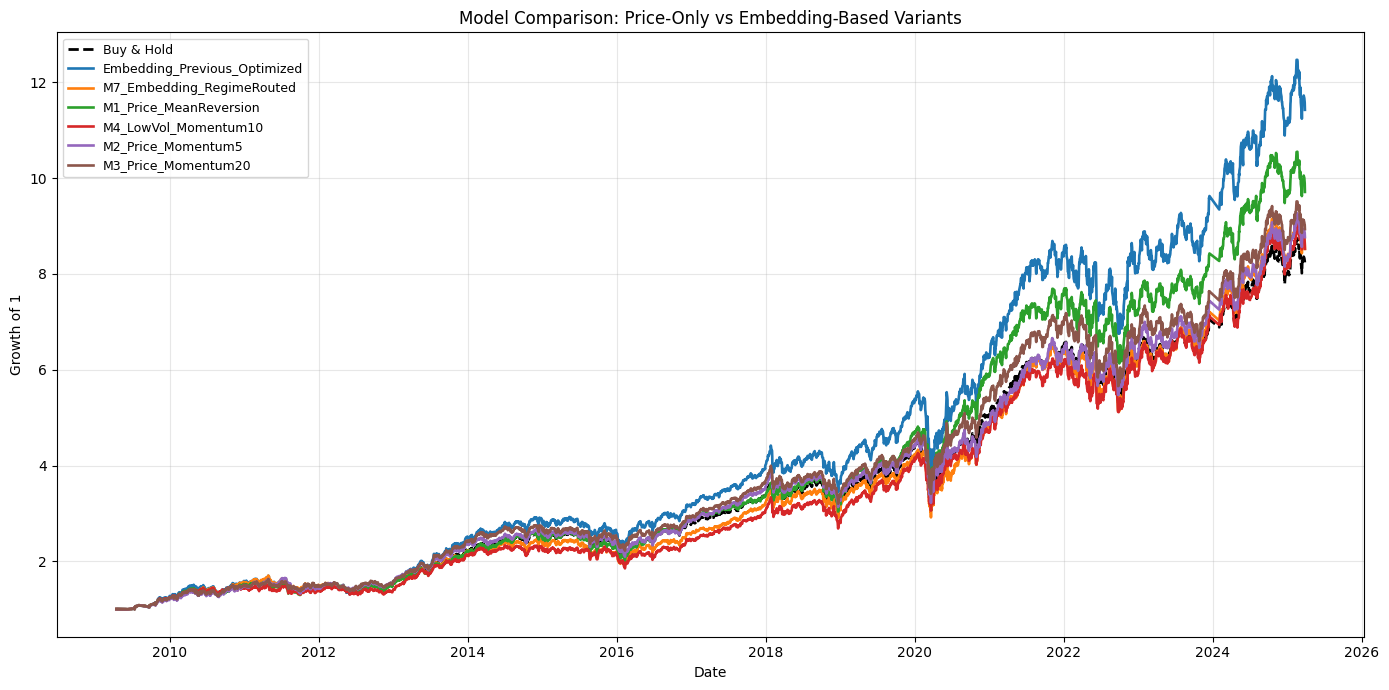

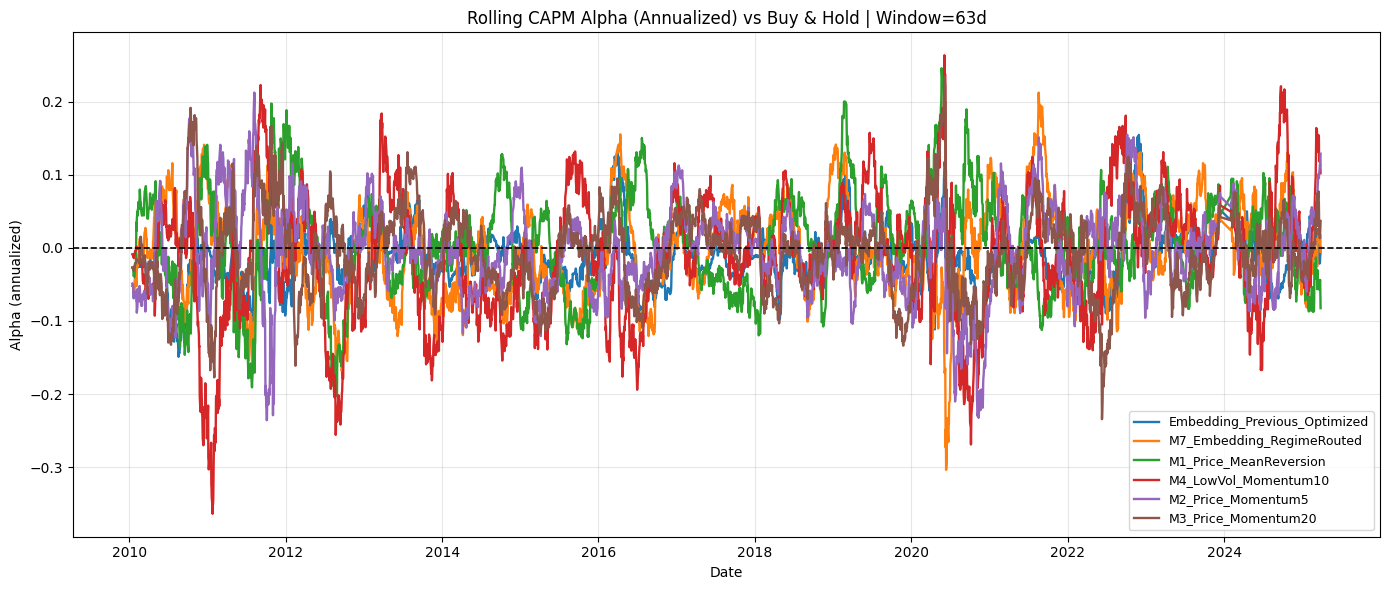

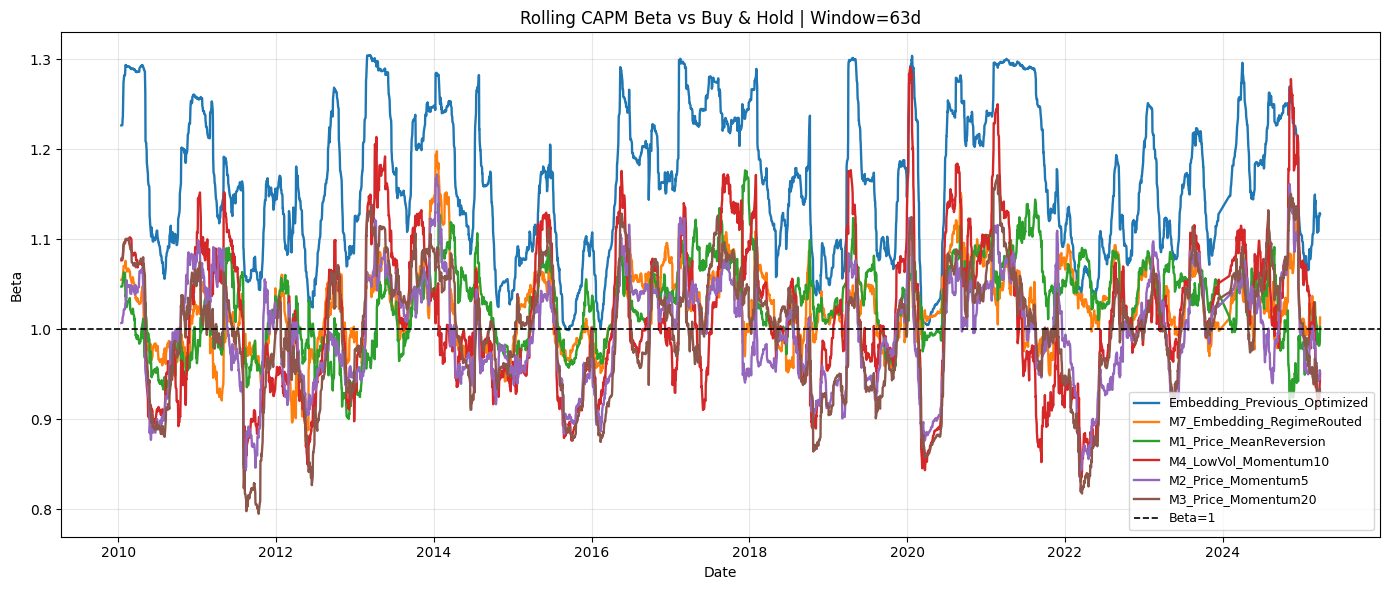

In [25]:
required_cmp = ["ret_df", "known_ret", "mask", "split", "intensity_df"]
missing_cmp = [v for v in required_cmp if v not in globals()]
if missing_cmp:
    raise ValueError(f"Run prior cells first. Missing: {missing_cmp}")

if "perf_stats" not in globals():
    def perf_stats(ret: pd.Series):
        ret = ret.fillna(0.0)
        total = (1.0 + ret).prod() - 1.0
        ann = (1.0 + total) ** (252.0 / max(len(ret), 1)) - 1.0
        vol = ret.std(ddof=0) * np.sqrt(252.0)
        sharpe = ann / vol if vol > 0 else 0.0
        return total, ann, vol, sharpe

def max_drawdown(ret: pd.Series):
    curve = (1.0 + ret.fillna(0.0)).cumprod()
    dd = curve / curve.cummax() - 1.0
    return float(dd.min())

def compute_alpha_beta(ret: pd.Series, bench: pd.Series, rf_annual: float = 0.0):
    rf_daily = (1.0 + rf_annual) ** (1.0 / 252.0) - 1.0
    x = bench.fillna(0.0).to_numpy() - rf_daily
    y = ret.fillna(0.0).to_numpy() - rf_daily
    var_x = np.var(x)
    beta = 0.0 if var_x <= 1e-12 else float(np.cov(y, x, ddof=0)[0, 1] / var_x)
    alpha_daily = float(np.mean(y) - beta * np.mean(x))
    alpha_ann = alpha_daily * 252.0
    return alpha_ann, beta

def compute_metrics(ret: pd.Series, bench: pd.Series, rf_annual: float = 0.0):
    total, ann, vol, sharpe = perf_stats(ret)
    mdd = max_drawdown(ret)
    calmar = ann / abs(mdd) if mdd < 0 else np.nan

    active = (ret.fillna(0.0) - bench.fillna(0.0))
    te = float(active.std(ddof=0) * np.sqrt(252.0))
    ir = float((active.mean() * 252.0) / te) if te > 0 else np.nan

    alpha_ann, beta = compute_alpha_beta(ret, bench, rf_annual=rf_annual)
    corr = float(np.corrcoef(ret.fillna(0.0).to_numpy(), bench.fillna(0.0).to_numpy())[0, 1])
    hit = float((ret.fillna(0.0) > 0).mean())

    return {
        "Total": total,
        "Ann": ann,
        "Vol": vol,
        "Sharpe": sharpe,
        "MaxDD": mdd,
        "Calmar": calmar,
        "AlphaAnn": alpha_ann,
        "Beta": beta,
        "CorrBench": corr,
        "TrackingErr": te,
        "InfoRatio": ir,
        "HitRate": hit,
    }

def rolling_alpha_beta(ret: pd.Series, bench: pd.Series, window: int = 63, rf_annual: float = 0.0):
    rf_daily = (1.0 + rf_annual) ** (1.0 / 252.0) - 1.0
    y = ret.fillna(0.0) - rf_daily
    x = bench.fillna(0.0).reindex(y.index).fillna(0.0) - rf_daily
    idx = y.index
    alpha_vals = np.full(len(idx), np.nan, dtype=float)
    beta_vals = np.full(len(idx), np.nan, dtype=float)

    for t in range(window - 1, len(idx)):
        y_w = y.iloc[t - window + 1 : t + 1].to_numpy()
        x_w = x.iloc[t - window + 1 : t + 1].to_numpy()
        var_x = np.var(x_w)
        beta = 0.0 if var_x <= 1e-12 else float(np.cov(y_w, x_w, ddof=0)[0, 1] / var_x)
        alpha_daily = float(np.mean(y_w) - beta * np.mean(x_w))
        alpha_vals[t] = alpha_daily * 252.0
        beta_vals[t] = beta

    return pd.Series(alpha_vals, index=idx), pd.Series(beta_vals, index=idx)

rf_annual = 0.0

ret_filled = ret_df.fillna(0.0)
bh_w = mask.div(mask.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
bh_ret = (bh_w * ret_filled).sum(axis=1)

market_known = known_ret.mean(axis=1)
mkt_trend = market_known.rolling(20, min_periods=10).mean().fillna(0.0)
vol_mkt = market_known.rolling(20, min_periods=10).std().bfill().fillna(0.0)
regime_cut = vol_mkt.iloc[:split].median() if split > 0 else vol_mkt.median()
regime_cmp = (vol_mkt > regime_cut).astype(float)
reg_mat = pd.DataFrame(
    np.repeat(regime_cmp.to_numpy()[:, None], ret_df.shape[1], axis=1),
    index=ret_df.index,
    columns=ret_df.columns,
 )

rev1 = -np.sign(known_ret).fillna(0.0)
mom5 = np.sign(known_ret.rolling(5, min_periods=3).mean()).fillna(0.0)
mom10 = np.sign(known_ret.rolling(10, min_periods=5).mean()).fillna(0.0)
mom20 = np.sign(known_ret.rolling(20, min_periods=10).mean()).fillna(0.0)

vol_asset = known_ret.rolling(20, min_periods=10).std()
lowvol_rank = vol_asset.rank(axis=1, pct=True, ascending=True)
lowvol_gate = (lowvol_rank >= 0.60).astype(float).fillna(0.0)

int_rank = intensity_df.rank(axis=1, pct=True)
hard70 = (int_rank >= 0.70).astype(float)
soft_gate = ((int_rank - 0.50).clip(lower=0.0) * 2.0).clip(upper=1.0)
int_accel = intensity_df.diff().fillna(0.0)
int_accel = int_accel.sub(int_accel.mean(axis=1), axis=0)
int_accel = int_accel.div(int_accel.std(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
int_accel_pos = int_accel.clip(lower=0.0)

signals_compare = {
    "M1_Price_MeanReversion": rev1,
    "M2_Price_Momentum5": mom5,
    "M3_Price_Momentum20": mom20,
    "M4_LowVol_Momentum10": lowvol_gate * mom10,
    "M5_Embedding_IntensityReversion": hard70 * rev1,
    "M6_Embedding_IntensityAccel_Mom10": int_accel_pos * mom10,
    "M7_Embedding_RegimeRouted": soft_gate * (reg_mat * rev1 + (1.0 - reg_mat) * mom5),
}

def build_tilt_cmp(raw_alpha: pd.DataFrame):
    x = (raw_alpha * mask).fillna(0.0)
    x = x.sub(x.mean(axis=1), axis=0)
    x = x.div(x.abs().sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
    return x

def run_overlay(raw_alpha: pd.DataFrame, k: float = 0.50, up: float = 1.10, down: float = 1.00):
    tilt = build_tilt_cmp(raw_alpha)
    exposure = pd.Series(np.where(mkt_trend > 0.0, up, down), index=ret_df.index)
    w_tilted = (bh_w + k * tilt).clip(lower=0.0)
    w_tilted = w_tilted.div(w_tilted.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
    base_ret = (w_tilted * ret_filled).sum(axis=1)
    return exposure * base_ret

curves_compare = {}
rows = []

for name, raw in signals_compare.items():
    series = run_overlay(raw, k=0.50, up=1.10, down=1.00)
    curves_compare[name] = series

    tr = series.iloc[:split]
    te = series.iloc[split:]
    bh_tr = bh_ret.iloc[:split]
    bh_te = bh_ret.iloc[split:]

    tr_metrics = compute_metrics(tr, bh_tr, rf_annual=rf_annual)
    te_metrics = compute_metrics(te, bh_te, rf_annual=rf_annual)

    rows.append(
        {
            "Model": name,
            "TrainTotal": tr_metrics["Total"],
            "TrainSharpe": tr_metrics["Sharpe"],
            "TestTotal": te_metrics["Total"],
            "TestSharpe": te_metrics["Sharpe"],
            "TestOutperfVsBH": te_metrics["Total"] - perf_stats(bh_te)[0],
            "TestAlphaAnn": te_metrics["AlphaAnn"],
            "TestBeta": te_metrics["Beta"],
            "TestVol": te_metrics["Vol"],
            "TestMaxDD": te_metrics["MaxDD"],
            "TestCalmar": te_metrics["Calmar"],
            "TestInfoRatio": te_metrics["InfoRatio"],
            "TestTrackingErr": te_metrics["TrackingErr"],
            "TestCorrBench": te_metrics["CorrBench"],
            "TestHitRate": te_metrics["HitRate"],
        }
    )

res_compare = pd.DataFrame(rows).set_index("Model")
res_compare = res_compare.sort_values(["TestOutperfVsBH", "TestAlphaAnn"], ascending=False)

if "best_ret" in globals():
    emb_prev = best_ret.reindex(ret_df.index).fillna(0.0)
    curves_compare["Embedding_Previous_Optimized"] = emb_prev
    tr = emb_prev.iloc[:split]
    te = emb_prev.iloc[split:]
    bh_tr = bh_ret.iloc[:split]
    bh_te = bh_ret.iloc[split:]

    tr_metrics = compute_metrics(tr, bh_tr, rf_annual=rf_annual)
    te_metrics = compute_metrics(te, bh_te, rf_annual=rf_annual)
    bh_te_total = perf_stats(bh_te)[0]
    res_compare.loc["Embedding_Previous_Optimized", :] = [
        tr_metrics["Total"],
        tr_metrics["Sharpe"],
        te_metrics["Total"],
        te_metrics["Sharpe"],
        te_metrics["Total"] - bh_te_total,
        te_metrics["AlphaAnn"],
        te_metrics["Beta"],
        te_metrics["Vol"],
        te_metrics["MaxDD"],
        te_metrics["Calmar"],
        te_metrics["InfoRatio"],
        te_metrics["TrackingErr"],
        te_metrics["CorrBench"],
        te_metrics["HitRate"],
    ]
    res_compare = res_compare.sort_values(["TestOutperfVsBH", "TestAlphaAnn"], ascending=False)

bh_total, bh_ann, bh_vol, bh_sharpe = perf_stats(bh_ret)
bh_mdd = max_drawdown(bh_ret)
print(f"Risk-free annual rate used in CAPM alpha/beta: {rf_annual:.2%}")
print(f"Buy&Hold total: {bh_total:.2%} | annual: {bh_ann:.2%} | vol: {bh_vol:.2%} | sharpe: {bh_sharpe:.3f} | maxDD: {bh_mdd:.2%}")
print("\nRanked by test outperformance and alpha vs Buy&Hold:")
print(res_compare.to_string(float_format=lambda x: f"{x:,.4f}"))

cum_bh = (1.0 + bh_ret).cumprod()
top_models = res_compare.index[:min(6, len(res_compare))].tolist()

plt.figure(figsize=(14, 7))
plt.plot(cum_bh.index, cum_bh.values, label="Buy & Hold", linestyle="--", linewidth=2.0, color="black")
for model_name in top_models:
    series = curves_compare[model_name]
    cum = (1.0 + series).cumprod()
    plt.plot(cum.index, cum.values, linewidth=1.9, label=model_name)

plt.title("Model Comparison: Price-Only vs Embedding-Based Variants")
plt.ylabel("Growth of 1")
plt.xlabel("Date")
plt.grid(alpha=0.3)
plt.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()

rolling_window = 63
alpha_ts = {}
beta_ts = {}
for model_name in top_models:
    a_s, b_s = rolling_alpha_beta(curves_compare[model_name], bh_ret, window=rolling_window, rf_annual=rf_annual)
    alpha_ts[model_name] = a_s
    beta_ts[model_name] = b_s

plt.figure(figsize=(14, 6))
for model_name in top_models:
    plt.plot(alpha_ts[model_name].index, alpha_ts[model_name].values, linewidth=1.7, label=model_name)
plt.axhline(0.0, color="black", linestyle="--", linewidth=1.2)
plt.title(f"Rolling CAPM Alpha (Annualized) vs Buy & Hold | Window={rolling_window}d")
plt.ylabel("Alpha (annualized)")
plt.xlabel("Date")
plt.grid(alpha=0.3)
plt.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
for model_name in top_models:
    plt.plot(beta_ts[model_name].index, beta_ts[model_name].values, linewidth=1.7, label=model_name)
plt.axhline(1.0, color="black", linestyle="--", linewidth=1.2, label="Beta=1")
plt.title(f"Rolling CAPM Beta vs Buy & Hold | Window={rolling_window}d")
plt.ylabel("Beta")
plt.xlabel("Date")
plt.grid(alpha=0.3)
plt.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from momentfm import MOMENTPipeline

selected_channels = ["Close", "rsi_14", "atr_14", "bb_bandwidth", "adx"]

def _build_technical_features(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=df.index)
    close = pd.to_numeric(df.get("Close"), errors="coerce")
    high = pd.to_numeric(df.get("High", close), errors="coerce")
    low = pd.to_numeric(df.get("Low", close), errors="coerce")

    out["Close"] = close

    delta = close.diff()
    gain = delta.clip(lower=0.0)
    loss = -delta.clip(upper=0.0)
    avg_gain = gain.rolling(14, min_periods=14).mean()
    avg_loss = loss.rolling(14, min_periods=14).mean()
    rs = avg_gain / (avg_loss + 1e-12)
    out["rsi_14"] = 100.0 - (100.0 / (1.0 + rs))

    prev_close = close.shift(1)
    tr = pd.concat([
        (high - low).abs(),
        (high - prev_close).abs(),
        (low - prev_close).abs(),
    ], axis=1).max(axis=1)
    out["atr_14"] = tr.rolling(14, min_periods=14).mean()

    ma20 = close.rolling(20, min_periods=20).mean()
    sd20 = close.rolling(20, min_periods=20).std(ddof=0)
    upper = ma20 + 2.0 * sd20
    lower = ma20 - 2.0 * sd20
    out["bb_bandwidth"] = (upper - lower) / (ma20.abs() + 1e-12)

    up_move = high.diff()
    down_move = -low.diff()
    plus_dm = pd.Series(np.where((up_move > down_move) & (up_move > 0), up_move, 0.0), index=df.index)
    minus_dm = pd.Series(np.where((down_move > up_move) & (down_move > 0), down_move, 0.0), index=df.index)
    tr14_sum = tr.rolling(14, min_periods=14).sum()
    plus_di = 100.0 * plus_dm.rolling(14, min_periods=14).sum() / (tr14_sum + 1e-12)
    minus_di = 100.0 * minus_dm.rolling(14, min_periods=14).sum() / (tr14_sum + 1e-12)
    dx = 100.0 * (plus_di - minus_di).abs() / (plus_di + minus_di + 1e-12)
    out["adx"] = dx.rolling(14, min_periods=14).mean()

    out = out.replace([np.inf, -np.inf], np.nan).ffill().bfill()
    out = out.fillna(0.0)
    return out

if "moment_model" not in globals() or moment_model is None:
    try:
        moment_model = MOMENTPipeline.from_pretrained(
            "AutonLab/MOMENT-1-large",
            model_kwargs={"task_name": "embedding"},
        )
        if hasattr(moment_model, "init"):
            moment_model.init()
        if hasattr(moment_model, "eval"):
            moment_model.eval()
        print("Instantiated MOMENT model successfully.")
    except Exception as e:
        raise RuntimeError(f"Failed to instantiate MOMENT model: {e}")

if "ticker_to_df" not in globals() or "ticker_to_X" not in globals() or not ticker_to_df or not ticker_to_X:
    ticker_to_df = {}
    ticker_to_X = {}

    top_n_for_moment = int(top_N) if "top_N" in globals() else 50
    if "top_n_df" in globals() and isinstance(top_n_df, pd.DataFrame) and "Ticker" in top_n_df.columns:
        candidate_tickers = top_n_df["Ticker"].astype(str).str.upper().head(top_n_for_moment).tolist()
    else:
        candidate_tickers = []
        ts_root = Path("data/time_series")
        for p in sorted(ts_root.glob("*.csv")):
            candidate_tickers.append(p.stem.upper())
        candidate_tickers = candidate_tickers[:top_n_for_moment]

    for ticker in candidate_tickers:
        ts_lower = Path("data/time_series") / f"{ticker.lower()}.csv"
        ts_upper = Path("data/time_series") / f"{ticker}.csv"
        ts_path = ts_lower if ts_lower.exists() else ts_upper
        if not ts_path.exists():
            continue

        raw = pd.read_csv(ts_path)
        if "Date" not in raw.columns or "Close" not in raw.columns:
            continue

        raw["Date"] = pd.to_datetime(raw["Date"], utc=True, errors="coerce").dt.tz_localize(None).dt.normalize()
        raw = raw.dropna(subset=["Date", "Close"]).sort_values("Date").reset_index(drop=True)
        if raw.empty:
            continue

        feats = _build_technical_features(raw)
        if any(ch not in feats.columns for ch in selected_channels):
            continue

        ticker_to_df[ticker] = raw
        ticker_to_X[ticker] = feats

    print(f"Built technical features for {len(ticker_to_df)} tickers.")

required_moment = ["ticker_to_df", "ticker_to_X", "cluster_df"]
missing_moment = [v for v in required_moment if v not in globals()]
if missing_moment:
    raise ValueError(f"Run prior technical-feature cells first. Missing: {missing_moment}")

cache_moment_dir = Path("cache/moment")
cache_moment_dir.mkdir(parents=True, exist_ok=True)

top_n_for_moment = int(top_N) if "top_N" in globals() else 50
emb_cache_path = cache_moment_dir / f"top{top_n_for_moment}_moment_embeddings.npy"
meta_cache_path = cache_moment_dir / f"top{top_n_for_moment}_moment_metadata.csv"

window_days = 30
min_window_len = 5
batch_size_moment = 32
recompute_moment = True

if emb_cache_path.exists() and meta_cache_path.exists():
    moment_emb = np.load(emb_cache_path, mmap_mode="r")
    moment_meta = pd.read_csv(meta_cache_path, parse_dates=["date"])
    if len(moment_meta) == moment_emb.shape[0] and moment_emb.ndim == 2:
        recompute_moment = False
        print(f"Loaded MOMENT cache: {moment_emb.shape}")
        print(f"Metadata rows: {len(moment_meta)}")
    else:
        print("MOMENT cache mismatch detected, recomputing.")

if recompute_moment:
    news_date_min = pd.to_datetime(cluster_df["date"], utc=True, errors="coerce").dt.tz_localize(None).dt.normalize().min()
    news_date_max = pd.to_datetime(cluster_df["date"], utc=True, errors="coerce").dt.tz_localize(None).dt.normalize().max()
    if pd.isna(news_date_min) or pd.isna(news_date_max):
        raise ValueError("Invalid news date range from cluster_df['date'].")
    news_date_min = max(news_date_min, pd.Timestamp("2020-01-01"))

    if "top_n_df" in globals() and isinstance(top_n_df, pd.DataFrame) and "Ticker" in top_n_df.columns:
        candidate_tickers = top_n_df["Ticker"].astype(str).str.upper().head(top_n_for_moment).tolist()
    else:
        candidate_tickers = sorted([str(k).upper() for k in ticker_to_df.keys()])[:top_n_for_moment]

    tickers = [t for t in candidate_tickers if t in ticker_to_df and t in ticker_to_X]
    if not tickers:
        raise ValueError("No overlapping tickers between top list and technical dictionaries.")

    multi_windows = []
    meta_rows = []

    print("=" * 80)
    print("MOMENT EMBEDDINGS: TOP-50 TICKERS")
    print("=" * 80)
    print(f"Ticker count: {len(tickers)}")
    print(f"News date range: {news_date_min} to {news_date_max}")
    print(f"Channels: {selected_channels}")

    for ti, ticker in enumerate(tickers, start=1):
        ticker_df = ticker_to_df[ticker].copy()
        if "Date" not in ticker_df.columns:
            continue

        ticker_df["Date"] = pd.to_datetime(ticker_df["Date"], utc=True, errors="coerce").dt.tz_localize(None).dt.normalize()
        ticker_df = ticker_df.dropna(subset=["Date"]).sort_values("Date")
        if ticker_df.empty:
            continue

        X_data = ticker_to_X[ticker]
        if not isinstance(X_data, pd.DataFrame):
            continue

        if any(ch not in X_data.columns for ch in selected_channels):
            continue
        channel_indices = [X_data.columns.get_loc(ch) for ch in selected_channels]

        filtered = ticker_df[(ticker_df["Date"] >= news_date_min) & (ticker_df["Date"] <= news_date_max)].copy()
        if filtered.empty:
            continue

        print(f"[{ti}/{len(tickers)}] {ticker}: {len(filtered)} target dates")

        for date_val in filtered["Date"].values:
            date_val = pd.Timestamp(date_val)
            window_start = date_val - pd.Timedelta(days=window_days)
            window_df = ticker_df[(ticker_df["Date"] >= window_start) & (ticker_df["Date"] <= date_val)].copy()
            if len(window_df) < min_window_len:
                continue

            idx = window_df.index
            if not np.all(np.isin(idx, X_data.index)):
                continue

            feat_all = X_data.loc[idx].to_numpy(dtype=np.float32)
            feat = feat_all[:, channel_indices]
            if feat.shape[0] < min_window_len or np.isnan(feat).any():
                continue

            close_vals = window_df["Close"].astype(float).to_numpy()
            log_ret = np.diff(np.log(close_vals)) if len(close_vals) > 1 else np.array([], dtype=float)
            vol_20d = float(np.std(log_ret) * np.sqrt(252.0)) if len(log_ret) > 1 else 0.0

            multi_windows.append(feat)
            meta_rows.append({
                "ticker": ticker,
                "date": date_val,
                "vol_20d": vol_20d,
                "n_days": int(len(window_df)),
            })

    if not multi_windows:
        raise ValueError("No valid multi-channel windows were prepared for MOMENT.")

    max_seq_len = max(w.shape[0] for w in multi_windows)
    padded = []
    for w in multi_windows:
        if w.shape[0] < max_seq_len:
            pad_len = max_seq_len - w.shape[0]
            w = np.pad(w, ((0, pad_len), (0, 0)), mode="edge").astype(np.float32)
        padded.append(w)

    print(f"Prepared windows: {len(padded)}")
    print(f"Padded shape per window: ({max_seq_len}, {len(selected_channels)})")

    all_emb = []
    with torch.no_grad():
        for i in range(0, len(padded), batch_size_moment):
            if i % (batch_size_moment * 20) == 0:
                print(f"Embedding batch [{i}/{len(padded)}]")
            batch_np = np.array(padded[i : i + batch_size_moment], dtype=np.float32)
            batch_t = torch.from_numpy(batch_np).transpose(1, 2)
            input_mask = torch.ones((batch_t.shape[0], batch_t.shape[2]), dtype=torch.long)
            out = moment_model(x_enc=batch_t, input_mask=input_mask)
            emb = out.embeddings
            if isinstance(emb, torch.Tensor):
                emb = emb.detach().cpu().numpy()
            emb = np.asarray(emb, dtype=np.float32)
            if emb.ndim > 2:
                emb = emb.reshape(emb.shape[0], -1)
            all_emb.append(emb)

    moment_emb = np.vstack(all_emb).astype(np.float32)
    moment_meta = pd.DataFrame(meta_rows)
    moment_meta["date"] = pd.to_datetime(moment_meta["date"])

    if len(moment_meta) != moment_emb.shape[0]:
        n = min(len(moment_meta), moment_emb.shape[0])
        moment_meta = moment_meta.iloc[:n].reset_index(drop=True)
        moment_emb = moment_emb[:n]

    np.save(emb_cache_path, moment_emb)
    moment_meta.to_csv(meta_cache_path, index=False)

    print(f"Saved MOMENT embeddings: {emb_cache_path}")
    print(f"Saved MOMENT metadata: {meta_cache_path}")
    print(f"Final shape: {moment_emb.shape}")

print("=" * 80)
print("MOMENT EMBEDDINGS READY")
print("=" * 80)
print(f"Embeddings shape: {moment_emb.shape}")
print(f"Metadata rows: {len(moment_meta)}")
if len(moment_meta) > 0:
    print(f"Ticker coverage: {moment_meta['ticker'].nunique()}")
    print(f"Date coverage: {moment_meta['date'].min()} to {moment_meta['date'].max()}")

MOMENT EMBEDDINGS: TOP-50 TICKERS
Ticker count: 49
News date range: 2020-01-01 00:00:00 to 2025-05-06 00:00:00
Channels: ['Close', 'rsi_14', 'atr_14', 'bb_bandwidth', 'adx']
[1/49] GE: 1317 target dates
[2/49] KO: 1317 target dates
[3/49] GLD: 1317 target dates
[4/49] CMCSA: 1317 target dates
[5/49] V: 1317 target dates
[6/49] USO: 1317 target dates
[7/49] COST: 1317 target dates
[8/49] GILD: 1317 target dates
[9/49] MRK: 1317 target dates
[10/49] NKE: 1317 target dates
[11/49] QQQ: 1317 target dates
[12/49] COP: 1317 target dates
[13/49] ABBV: 1317 target dates
[14/49] XLF: 1317 target dates
[15/49] BABA: 1317 target dates
[16/49] AMGN: 1317 target dates
[17/49] T: 1317 target dates
[18/49] XLE: 1317 target dates
[19/49] CRM: 1317 target dates
[20/49] ORCL: 1317 target dates
[21/49] QCOM: 1317 target dates
[22/49] CAT: 1317 target dates
[23/49] BHP: 1317 target dates
[24/49] GSK: 1317 target dates
[25/49] PEP: 1317 target dates
[26/49] MU: 1317 target dates
[27/49] WFC: 1317 target da

HMM fitted on text plus numerical embeddings from 2020 onward
  High-quality state: 2
  Low-quality state: 0
  Text PCA shape: (1285, 3)
  Numerical PCA shape: (1285, 3)
  Combined feature shape: (1285, 6)
  Best strategy: HMM_TextNumerical_Routed|k0.50|up1.30|down0.40
  Strategy total: 113.45% | annual: 16.03% | vol: 17.05% | sharpe: 0.940
  Buy&Hold total: 84.78% | annual: 12.80% | vol: 20.66% | sharpe: 0.619


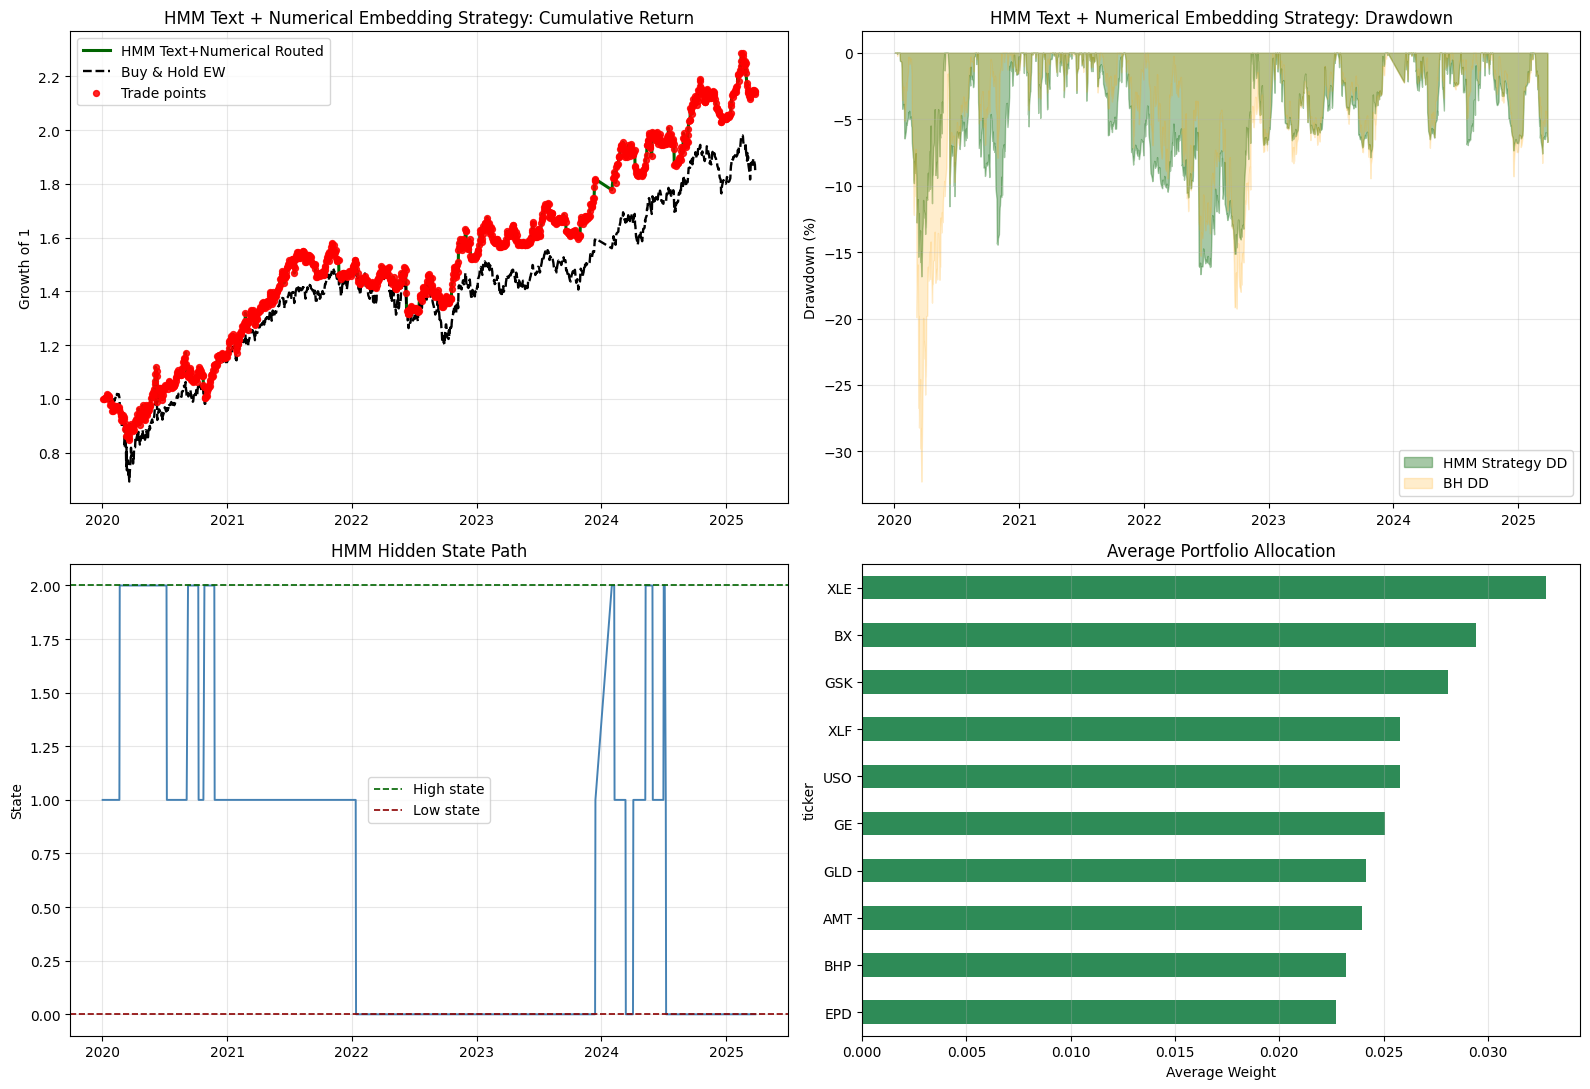

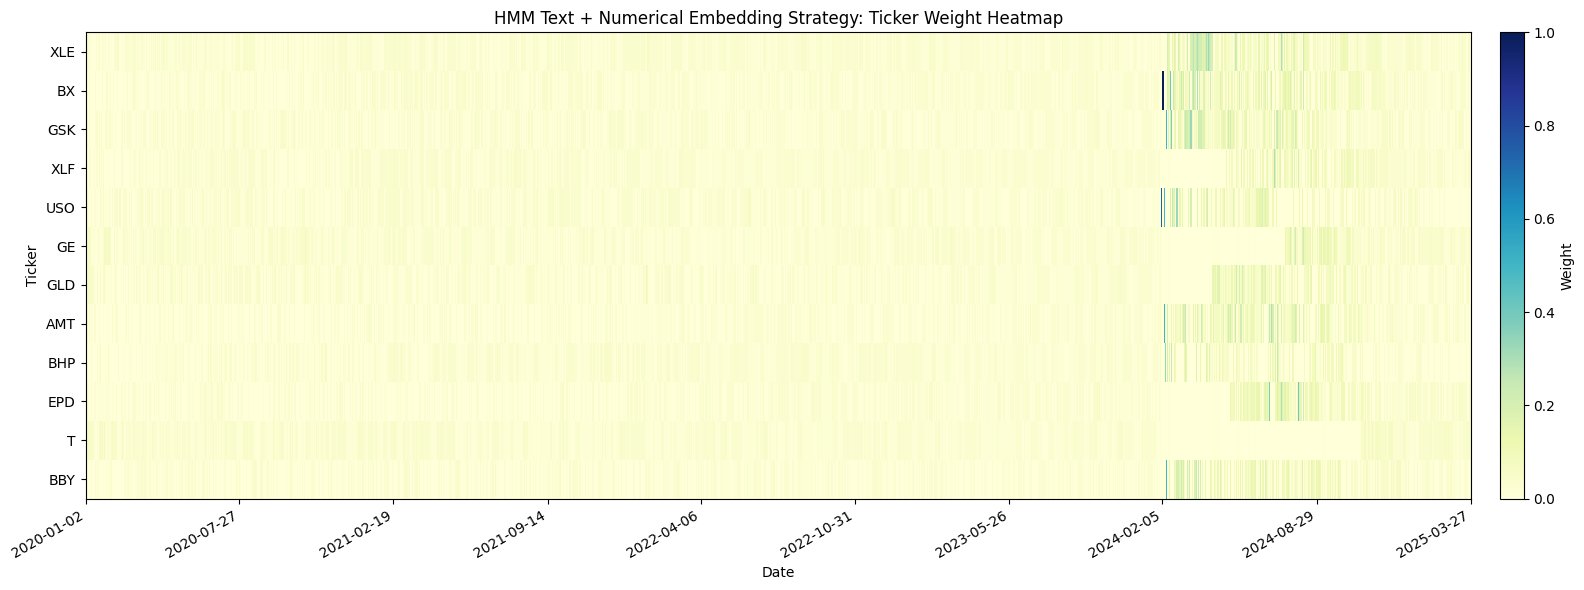

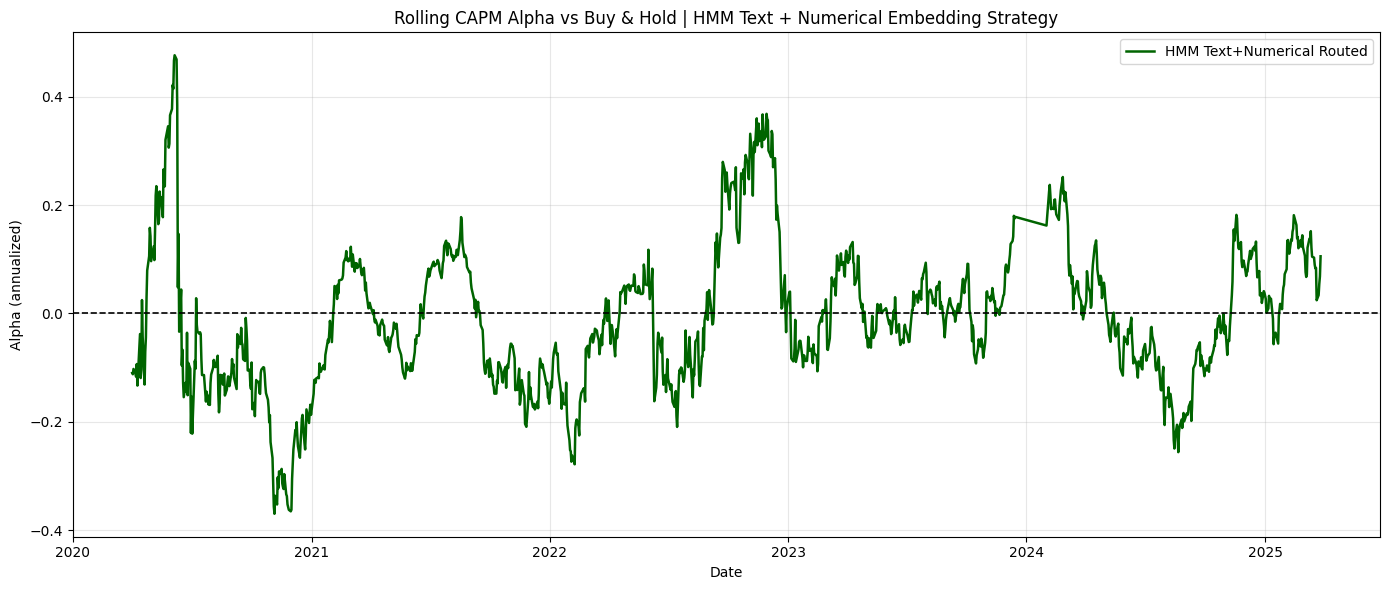

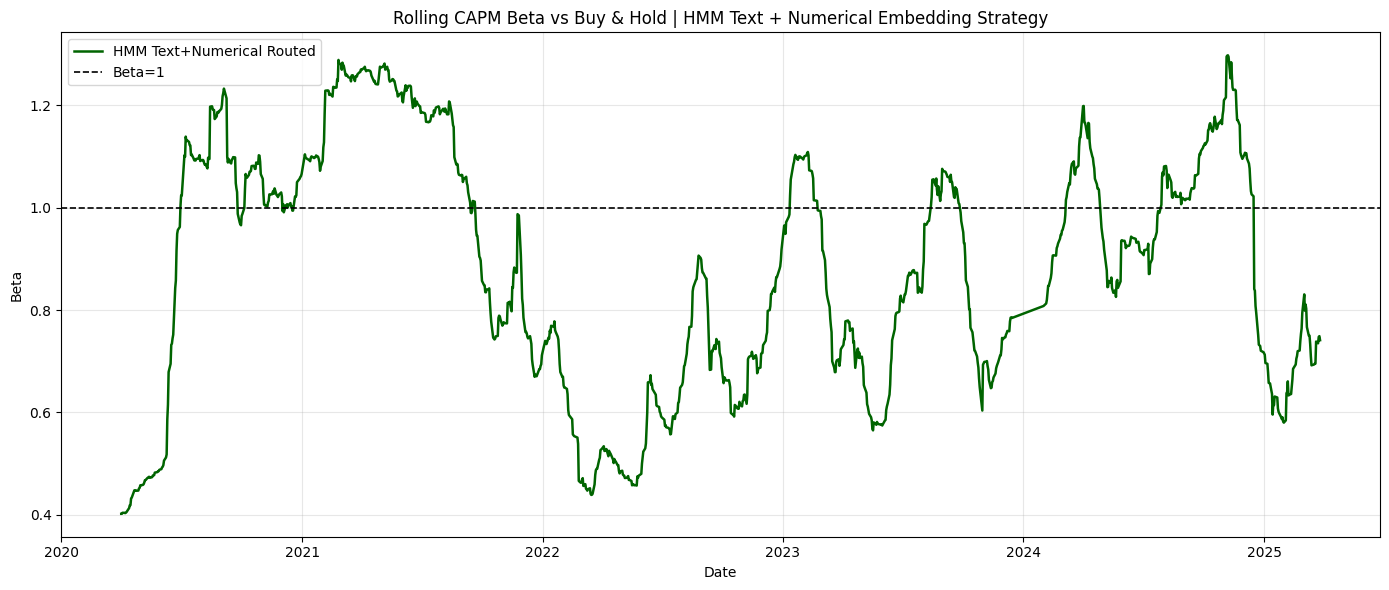

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from hmmlearn import hmm

required = ["ret_df", "known_ret", "mask", "x_text", "cluster_df", "intensity_df"]
missing = [v for v in required if v not in globals()]
if missing:
    raise ValueError(f"Run prior cells first. Missing: {missing}")

start_cutoff = pd.Timestamp("2020-01-01")
ret_df_2020 = ret_df.loc[ret_df.index >= start_cutoff].copy()
known_ret_2020 = known_ret.loc[known_ret.index >= start_cutoff].copy()
intensity_df_2020 = intensity_df.loc[intensity_df.index >= start_cutoff].copy()
mask_2020 = mask.loc[mask.index >= start_cutoff].copy()

if ret_df_2020.empty:
    raise ValueError("No return data available from 2020 onward.")

split_2020 = max(2, int(0.7 * len(ret_df_2020)))

if "perf_stats" not in globals():
    def perf_stats(ret: pd.Series):
        ret = ret.fillna(0.0)
        total = (1.0 + ret).prod() - 1.0
        ann = (1.0 + total) ** (252.0 / max(len(ret), 1)) - 1.0
        vol = ret.std(ddof=0) * np.sqrt(252.0)
        sharpe = ann / vol if vol > 0 else 0.0
        return total, ann, vol, sharpe


def max_drawdown(ret: pd.Series):
    curve = (1.0 + ret.fillna(0.0)).cumprod()
    dd = curve / curve.cummax() - 1.0
    return float(dd.min())


def rolling_alpha_beta(ret: pd.Series, bench: pd.Series, window: int = 63, rf_annual: float = 0.0):
    rf_daily = (1.0 + rf_annual) ** (1.0 / 252.0) - 1.0
    y = ret.fillna(0.0) - rf_daily
    x = bench.fillna(0.0).reindex(y.index).fillna(0.0) - rf_daily
    idx = y.index
    alpha_vals = np.full(len(idx), np.nan, dtype=float)
    beta_vals = np.full(len(idx), np.nan, dtype=float)

    for t in range(window - 1, len(idx)):
        y_w = y.iloc[t - window + 1 : t + 1].to_numpy()
        x_w = x.iloc[t - window + 1 : t + 1].to_numpy()
        var_x = np.var(x_w)
        beta = 0.0 if var_x <= 1e-12 else float(np.cov(y_w, x_w, ddof=0)[0, 1] / var_x)
        alpha_daily = float(np.mean(y_w) - beta * np.mean(x_w))
        alpha_vals[t] = alpha_daily * 252.0
        beta_vals[t] = beta

    return pd.Series(alpha_vals, index=idx), pd.Series(beta_vals, index=idx)


def build_tilt(raw_alpha: pd.DataFrame):
    x = (raw_alpha * mask_2020).fillna(0.0)
    x = x.sub(x.mean(axis=1), axis=0)
    x = x.div(x.abs().sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
    return x


ret_filled_2020 = ret_df_2020.fillna(0.0)
bh_w_2020 = mask_2020.div(mask_2020.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
bh_ret_2020 = (bh_w_2020 * ret_filled_2020).sum(axis=1)
market_known_2020 = known_ret_2020.mean(axis=1)
mkt_trend_2020 = market_known_2020.rolling(20, min_periods=10).mean().fillna(0.0)

emb_dates = pd.to_datetime(cluster_df["date"], errors="coerce", utc=True).dt.tz_localize(None).dt.normalize()
emb_df = pd.DataFrame(np.asarray(x_text, dtype=np.float32))
emb_df["date"] = emb_dates.values
emb_df = emb_df.dropna(subset=["date"])
text_daily = emb_df.groupby("date", as_index=True).mean(numeric_only=True)
text_daily = text_daily.reindex(ret_df_2020.index).interpolate(method="linear", limit_direction="both").bfill().ffill()

num_features = pd.DataFrame(index=ret_df_2020.index)
num_features["market_mean_ret"] = market_known_2020
num_features["market_abs_ret"] = known_ret_2020.abs().mean(axis=1)
num_features["market_breadth"] = (known_ret_2020 > 0.0).mean(axis=1)
num_features["market_intensity_mean"] = intensity_df_2020.mean(axis=1)
num_features["market_intensity_std"] = intensity_df_2020.std(axis=1)
num_features["market_intensity_mom5"] = intensity_df_2020.mean(axis=1).rolling(5, min_periods=3).mean()
num_features["market_ret_mom5"] = market_known_2020.rolling(5, min_periods=3).mean()
num_features["market_ret_mom10"] = market_known_2020.rolling(10, min_periods=5).mean()
num_features["market_vol20"] = market_known_2020.rolling(20, min_periods=10).std()
num_features = num_features.bfill().ffill().fillna(0.0)

text_values = text_daily.to_numpy(dtype=float)
num_values = num_features.to_numpy(dtype=float)

text_train = text_values[:split_2020]
num_train = num_values[:split_2020]

text_mean = text_train.mean(axis=0)
text_std = np.where(text_train.std(axis=0) < 1e-8, 1.0, text_train.std(axis=0))
num_mean = num_train.mean(axis=0)
num_std = np.where(num_train.std(axis=0) < 1e-8, 1.0, num_train.std(axis=0))

text_scaled = np.nan_to_num((text_values - text_mean) / text_std, nan=0.0, posinf=0.0, neginf=0.0)
num_scaled = np.nan_to_num((num_values - num_mean) / num_std, nan=0.0, posinf=0.0, neginf=0.0)

text_centered = text_scaled[:split_2020] - text_scaled[:split_2020].mean(axis=0, keepdims=True)
num_centered = num_scaled[:split_2020] - num_scaled[:split_2020].mean(axis=0, keepdims=True)

_, _, vt_text = np.linalg.svd(text_centered, full_matrices=False)
_, _, vt_num = np.linalg.svd(num_centered, full_matrices=False)

text_pcs = min(3, vt_text.shape[0])
num_pcs = min(3, vt_num.shape[0])
text_features = text_scaled @ vt_text[:text_pcs].T
num_features_pcs = num_scaled @ vt_num[:num_pcs].T

if text_pcs < 3:
    text_features = np.pad(text_features, ((0, 0), (0, 3 - text_pcs)), mode="constant")
if num_pcs < 3:
    num_features_pcs = np.pad(num_features_pcs, ((0, 0), (0, 3 - num_pcs)), mode="constant")

combined_features = np.hstack([text_features[:, :3], num_features_pcs[:, :3]])
combined_train = combined_features[:split_2020]
combined_train = combined_train - combined_train.mean(axis=0, keepdims=True)
combined_scale = combined_train.std(axis=0)
combined_scale = np.where(combined_scale < 1e-8, 1.0, combined_scale)
combined_features = combined_features / combined_scale
combined_train = combined_features[:split_2020]

hmm_model = hmm.GaussianHMM(n_components=3, covariance_type="diag", random_state=42, n_iter=200)
hmm_model.fit(combined_train)
hmm_states = hmm_model.predict(combined_features)

state_quality = []
for state_id in range(hmm_model.n_components):
    state_mask = hmm_states[:split_2020] == state_id
    state_quality.append(float(bh_ret_2020.iloc[:split_2020][state_mask].mean()) if state_mask.any() else -np.inf)

high_state = int(np.nanargmax(state_quality))
low_state = int(np.nanargmin(state_quality))
regime_signal = pd.Series((hmm_states == high_state).astype(float), index=ret_df_2020.index)
regime_mat = pd.DataFrame(
    np.repeat(regime_signal.to_numpy()[:, None], ret_df_2020.shape[1], axis=1),
    index=ret_df_2020.index,
    columns=ret_df_2020.columns,
)

rev1 = -np.sign(known_ret_2020).fillna(0.0)
mom5 = np.sign(known_ret_2020.rolling(5, min_periods=3).mean()).fillna(0.0)
raw_signal = regime_mat * rev1 + (1.0 - regime_mat) * mom5
raw_signal = raw_signal.astype(float)

records = []
curves = {}

for k in [0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]:
    for up in [1.00, 1.10, 1.20, 1.30]:
        for down in [0.20, 0.40, 0.60, 0.80, 1.00]:
            exposure = pd.Series(np.where(mkt_trend_2020 > 0.0, up, down), index=ret_df_2020.index)
            tilt = build_tilt(raw_signal)
            w_tilted = (bh_w_2020 + k * tilt).clip(lower=0.0)
            w_tilted = w_tilted.div(w_tilted.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
            base_ret = (w_tilted * ret_filled_2020).sum(axis=1)
            strat_ret = exposure * base_ret

            tr = strat_ret.iloc[:split_2020]
            te = strat_ret.iloc[split_2020:]
            bh_te = bh_ret_2020.iloc[split_2020:]

            tr_total, tr_ann, tr_vol, tr_sharpe = perf_stats(tr)
            te_total, te_ann, te_vol, te_sharpe = perf_stats(te)
            bh_te_total, _, _, _ = perf_stats(bh_te)

            key = f"HMM_TextNumerical_Routed|k{k:.2f}|up{up:.2f}|down{down:.2f}"
            curves[key] = strat_ret
            train_score = tr_sharpe + 0.50 * tr_total - 0.25 * tr_vol
            records.append(
                {
                    "Key": key,
                    "k": k,
                    "up": up,
                    "down": down,
                    "TrainScore": train_score,
                    "TrainTotal": tr_total,
                    "TrainSharpe": tr_sharpe,
                    "TestTotal": te_total,
                    "TestSharpe": te_sharpe,
                    "TestOutperfVsBH": te_total - bh_te_total,
                }
            )

res = pd.DataFrame(records).set_index("Key")
res = res.sort_values(["TrainScore", "TestOutperfVsBH"], ascending=False)
best_key = res.index[0]
best_ret = curves[best_key]

best_total, best_ann, best_vol, best_sharpe = perf_stats(best_ret)
bh_total, bh_ann, bh_vol, bh_sharpe = perf_stats(bh_ret_2020)

print("HMM fitted on text plus numerical embeddings from 2020 onward")
print(f"  High-quality state: {high_state}")
print(f"  Low-quality state: {low_state}")
print(f"  Text PCA shape: {text_features.shape}")
print(f"  Numerical PCA shape: {num_features_pcs.shape}")
print(f"  Combined feature shape: {combined_features.shape}")
print(f"  Best strategy: {best_key}")
print(f"  Strategy total: {best_total:.2%} | annual: {best_ann:.2%} | vol: {best_vol:.2%} | sharpe: {best_sharpe:.3f}")
print(f"  Buy&Hold total: {bh_total:.2%} | annual: {bh_ann:.2%} | vol: {bh_vol:.2%} | sharpe: {bh_sharpe:.3f}")

cum_best = (1.0 + best_ret).cumprod()
cum_bh = (1.0 + bh_ret_2020).cumprod()
dd_best = (cum_best / cum_best.cummax() - 1.0) * 100.0
dd_bh = (cum_bh / cum_bh.cummax() - 1.0) * 100.0

best_tilt = build_tilt(raw_signal)
weights_by_date = (bh_w_2020 + 0.50 * best_tilt).clip(lower=0.0)
weights_by_date = weights_by_date.div(weights_by_date.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
weights_by_date = weights_by_date.mul(pd.Series(np.where(mkt_trend_2020 > 0.0, 1.10, 1.00), index=weights_by_date.index), axis=0)
weights_by_date = weights_by_date.div(weights_by_date.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
trade_points = weights_by_date.diff().abs().sum(axis=1).fillna(0.0) > 1e-9

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.ravel()

axes[0].plot(cum_best.index, cum_best.values, label="HMM Text+Numerical Routed", linewidth=2.2, color="darkgreen")
axes[0].plot(cum_bh.index, cum_bh.values, label="Buy & Hold EW", linestyle="--", linewidth=1.7, color="black")
trade_dates = trade_points[trade_points].index
trade_vals = cum_best.reindex(trade_dates).dropna()
axes[0].scatter(trade_vals.index, trade_vals.values, s=18, color="red", alpha=0.85, label="Trade points", zorder=5)
axes[0].set_title("HMM Text + Numerical Embedding Strategy: Cumulative Return")
axes[0].set_ylabel("Growth of 1")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].fill_between(dd_best.index, dd_best.values, 0.0, alpha=0.35, label="HMM Strategy DD", color="darkgreen")
axes[1].fill_between(dd_bh.index, dd_bh.values, 0.0, alpha=0.20, label="BH DD", color="orange")
axes[1].set_title("HMM Text + Numerical Embedding Strategy: Drawdown")
axes[1].set_ylabel("Drawdown (%)")
axes[1].grid(alpha=0.3)
axes[1].legend()

state_series = pd.Series(hmm_states, index=ret_df_2020.index)
axes[2].plot(state_series.index, state_series.values, linewidth=1.4, color="steelblue")
axes[2].axhline(high_state, color="darkgreen", linestyle="--", linewidth=1.2, label="High state")
axes[2].axhline(low_state, color="darkred", linestyle="--", linewidth=1.2, label="Low state")
axes[2].set_title("HMM Hidden State Path")
axes[2].set_ylabel("State")
axes[2].grid(alpha=0.3)
axes[2].legend()

mean_w = weights_by_date.mean().sort_values(ascending=False)
mean_w = mean_w[mean_w > 0]
if not mean_w.empty:
    mean_w.head(10).iloc[::-1].plot(kind="barh", ax=axes[3], color="seagreen")
    axes[3].set_title("Average Portfolio Allocation")
    axes[3].set_xlabel("Average Weight")
    axes[3].grid(axis="x", alpha=0.3)
else:
    axes[3].axis("off")

plt.tight_layout()
plt.show()

heat_tickers = mean_w.head(12).index.tolist() if not mean_w.empty else list(weights_by_date.columns[:12])
heat_df = weights_by_date[heat_tickers].copy() if len(heat_tickers) > 0 else weights_by_date.iloc[:, :0].copy()
if heat_df.shape[1] > 0:
    fig, ax = plt.subplots(figsize=(16, 6))
    im = ax.imshow(heat_df.T.values, aspect="auto", cmap="YlGnBu", interpolation="nearest")
    ax.set_title("HMM Text + Numerical Embedding Strategy: Ticker Weight Heatmap")
    ax.set_ylabel("Ticker")
    ax.set_xlabel("Date")
    ax.set_yticks(np.arange(heat_df.shape[1]))
    ax.set_yticklabels(heat_df.columns)
    x_ticks = np.linspace(0, heat_df.shape[0] - 1, min(10, heat_df.shape[0])).astype(int)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([pd.Timestamp(heat_df.index[i]).strftime("%Y-%m-%d") for i in x_ticks], rotation=30, ha="right")
    fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label="Weight")
    plt.tight_layout()
    plt.show()

alpha_ts, beta_ts = rolling_alpha_beta(best_ret, bh_ret_2020, window=63)
plt.figure(figsize=(14, 6))
plt.plot(alpha_ts.index, alpha_ts.values, linewidth=1.8, color="darkgreen", label="HMM Text+Numerical Routed")
plt.axhline(0.0, color="black", linestyle="--", linewidth=1.2)
plt.title("Rolling CAPM Alpha vs Buy & Hold | HMM Text + Numerical Embedding Strategy")
plt.ylabel("Alpha (annualized)")
plt.xlabel("Date")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
plt.plot(beta_ts.index, beta_ts.values, linewidth=1.8, color="darkgreen", label="HMM Text+Numerical Routed")
plt.axhline(1.0, color="black", linestyle="--", linewidth=1.2, label="Beta=1")
plt.title("Rolling CAPM Beta vs Buy & Hold | HMM Text + Numerical Embedding Strategy")
plt.ylabel("Beta")
plt.xlabel("Date")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()